# Quantum Darwinism is not enough: Consistency of facts in Wigner’s Friend Scenarios

**Quantum Information Table**

| Concept                  | Meaning                                                   | Formula (plain text)                          |
|---------------------------|-----------------------------------------------------------|-----------------------------------------------|
| Von Neumann Entropy (VNE) | Measures uncertainty of a quantum state                   | H(rho) = -Tr(rho log2 rho)                    |
| Quantum Mutual Information (QMI) | Total correlations (classical + quantum) between system and environment | I(S:E) = H(S) + H(E) - H(SE)                  |
| Holevo Information (Chi)  | Upper bound on classical accessible information           | Chi = H(sum_i p_i rho_i) - sum_i p_i H(rho_i) |
| Quantum Discord           | Difference between QMI and classical correlations         | Discord = QMI - Classical correlations        |


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_91234/85519465.py:70: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SE @ rho_SE))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_91234/85519465.py:70: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SE @ rho_SE))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_91234/85519465.py:70: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SE @ rho_SE))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_91234/85519465.py:72: RuntimeWarning: divide by zero encountered in matmul
  rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_91234/85519465.py:72: RuntimeWarning: overflow encountered in matmul
  rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_91234/85519465.py:72: RuntimeWarning: invalid value enco

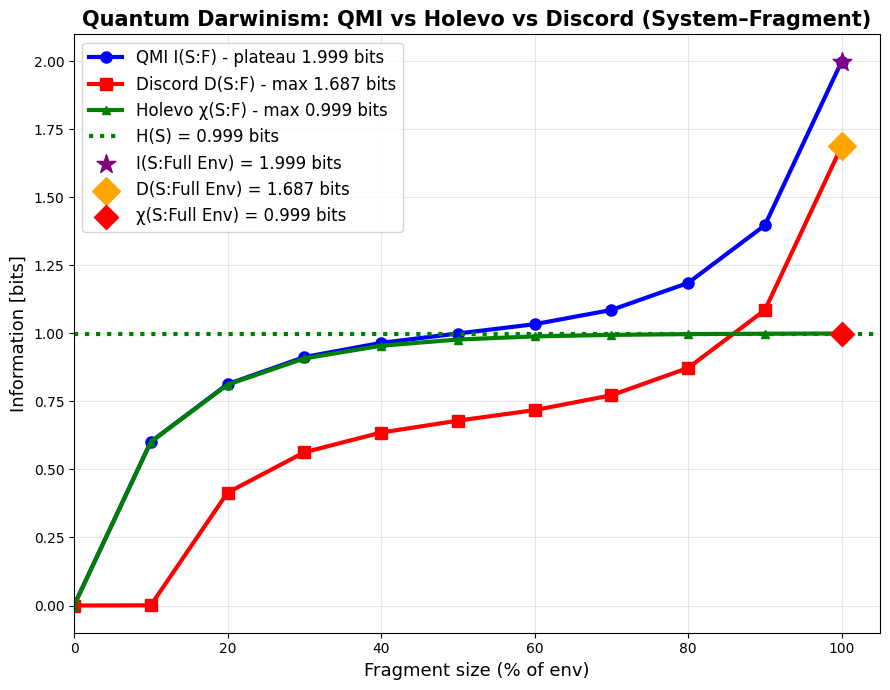

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


In [ ]:
# Quantum Darwinism: System + Environment fragments (pi/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        
        # System prepare |+>
        qc.u(self.theta, self.phi, 0, qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 
    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    # Holevo bound χ(S:F) = S(ρ_E) - Σ p_i S(ρ_E^i)
    def HolevoBound(self, state): 
        vne = self.VNE(state)
        eigenvalues, eigenvectors = np.linalg.eigh(state)
        sumX = 0
        for i in range(len(eigenvalues)): 
            vec = eigenvectors[:, i]
            pure_state = np.outer(vec, np.conjugate(vec))
            sumX += eigenvalues[i] * self.VNE(pure_state)
        return vne - sumX
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F)
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        eigvals, eigvecs = np.linalg.eigh(rho_S)
        cond_entropy = 0
        d_E = rho_SE.shape[0] // rho_S.shape[0]
        
        for i in range(len(eigvals)):
            proj_S = np.outer(eigvecs[:, i], np.conj(eigvecs[:, i]))
            proj_SE = np.kron(proj_S, np.eye(d_E))
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 11  # q0 system, q1..q10 environment
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(1, numQubits))

results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):

    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)

    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_Ef)
    results_Holevo.append(Holevo_Ef)
    # Quantum Discord
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)


rho_E_full  = qc.get_reduced_dm(env_qubits)

rho_SE_full = qc.get_reduced_dm([0]+env_qubits)

QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

Holevo_E_full = QI_calc.HolevoBound(rho_E_full)

Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,
    "QMI_S_Efull": QMI_S_Efull,
    "Holevo_E_full": Holevo_E_full,
    "Discord_SE_full": Discord_SE_full
}

with open("quantum_darwinism_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_QMI_Holevo_Discord.pkl")



In [ ]:
# Original source code (Quantum Darwinism simulation)
from qiskit import QuantumCircuit 
from qiskit import quantum_info as qi 
from qiskit.quantum_info import DensityMatrix
from qiskit.quantum_info import partial_trace
from scipy.linalg import logm 
import math  
import numpy as np
import matplotlib.pyplot as plt

class QCircuit():   
    def __init__(self, theta, phi, n): 
        self.theta = theta 
        self.phi = phi 
        self.n = n

    def Circuit(self): 
        qc = QuantumCircuit(self.n, self.n) 
        qc.u(self.theta,self.phi,0,0)
        for i in range(1, self.n): 
            qc.cu(self.theta,self.phi,0,0,0,i)
        #qc.measure_all()
        return qc 
    
    def DensityMatrix(self): 
        dm = qi.DensityMatrix.from_instruction(self.Circuit())
        return dm 
    
    def reduced_state(self, index):
        rho = self.DensityMatrix()
        reduced_state = partial_trace(rho, index)
        return reduced_state 

class QuantumInformation(): 
    #def __init__(self, S_State, E_State, SE_State ): 
        #self.S_State = S_State 
        #self.E_State = E_State 
        #self.SE_State = SE_State 
    
    def VNE(self, state):
        vne = 0.0
        eigenvalues, _ = np.linalg.eigh(state)
        for i in eigenvalues:
            if i > 0: 
                vne += - (i * np.log2(i))
        return vne 
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S = self.VNE(S_State)
        VNE_E = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        mutual = VNE_S + VNE_E - VNE_SE 
        return mutual 
    

    def quantum_discord(self, reduced_SE, reduced_S):
        conditional_entropies = []
        mutual_information = self.mutual_information(reduced_S, reduced_SE)  # Calculate mutual information
        for projector in np.linalg.eigh(reduced_S)[1]:
            proj = projector.data
            p_A_i = np.trace((proj @ reduced_SE) @ proj)
            if p_A_i > 0:
                reduced_SE_i = (proj @ reduced_SE @ proj) / p_A_i
                rho_B_i = partial_trace(DensityMatrix(reduced_SE_i), [0]).data
                conditional_entropies.append(p_A_i * self.VNE(rho_B_i))
        # Consider mutual information or alternative redundancy measure
        total_discord = np.sum(conditional_entropies) - mutual_information
        return total_discord
    
    def HolevoBound(self, state): 
        holBound = 0 
        vne = self.VNE(state)
        eigenvalues, eigenvectors = np.linalg.eigh(state)
        sumX = 0
        for i in range(0, len(eigenvalues)): 
            sumX += (eigenvalues[i] * self.VNE(np.outer(eigenvectors[i], np.conjugate(eigenvectors[i]))))
        holBound = vne - sumX
        return holBound 
    
numQubits = 10
fs = np.linspace(0,1,numQubits)
QMI = [0] 
indexQ = list(range(0, numQubits))
indexS = list(np.delete(indexQ, 0))
indexE = indexQ
indexSE = indexS

for i in range(numQubits-1): 
    qc = QCircuit(np.pi / 2 , 0 , numQubits ) 
    rho =  qc.DensityMatrix() 
    #S state
    reduced_S = qc.reduced_state(index = indexS) 
    #E state
    indexE = list(np.delete(indexE,1))
    reduced_E = qc.reduced_state(index = indexE) 
    #SE state
    indexSE = list(np.delete(indexSE,0))
    reduced_SE1 = qc.reduced_state(index = indexSE) 
    
    QI = QuantumInformation()
    QM = QI.quantum_mutual_I(reduced_S, reduced_E, reduced_SE1)
    QMI.append(QM)
    entropy_system = QI.VNE(reduced_S)

fig = plt.figure(figsize=(8, 6))
plt.plot(fs, QMI, label = "Quantum Mutual Information")
plt.plot(fs, [entropy_system]*len(fs), label = "H(s)")
plt.plot(fs, [ 2 * entropy_system]*len(fs), label = "2*H(s)")
plt.savefig(f"QuantumInformationVsF_{numQubits}.png")








#QM = QI.quantum_mutual(reduced_S, reduced_E, reduced_SE1)
#print("Quantum Mutual Value :", QM)

#HolevoBound = QI.Holevo_Bound(reduced_S, reduced_SE1)
#print("Holevo Bound Value :", HolevoBound)

#HolevoBound = QI.Holevo_Bound(reduced_SE1.data, reduced_S.data)
#print("Holevo Bound Value :", HolevoBound)

#QD = QI.quantum_discord(reduced_E, reduced_SE1, reduced_S)
#print("Quantum Discord Value :" , QD) 


KeyboardInterrupt: 

**Quantum mutual information (QMI)** 
- Comparing between different model:

    - Model only contains system qubit and environment qubits.
    
    - Model contains system qubit, obsever qubit, and environment qubits
---

Quantum Darwinism Simulation (n=11 qubits)


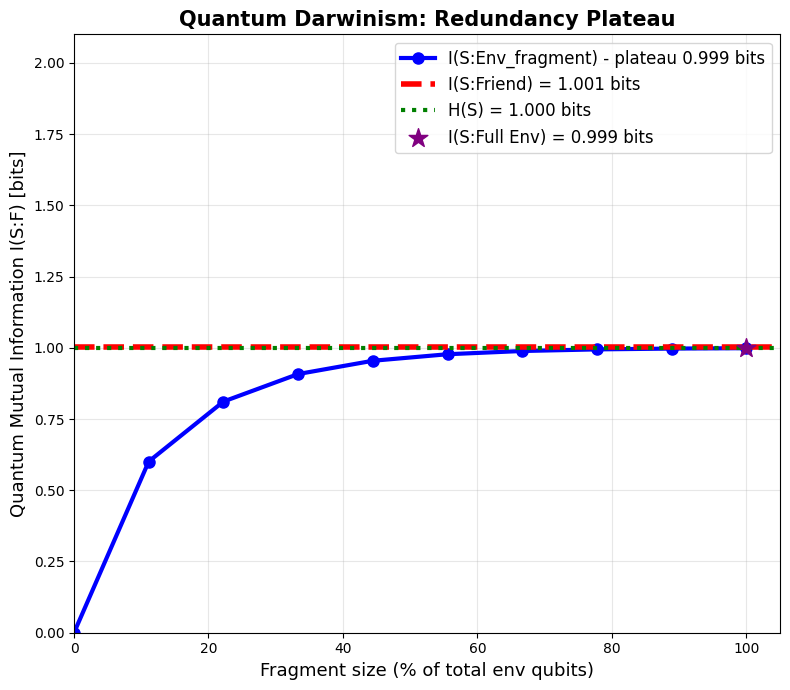


RESULTS:
H(S)              = 1.000 bits
I(S:Friend)       = 1.001 bits (100.1% of H(S))
I(S:Full Env)     = 0.999 bits (99.9% of 2H(S))
Max fragment I    = 0.999 bits


<Figure size 640x480 with 0 Axes>

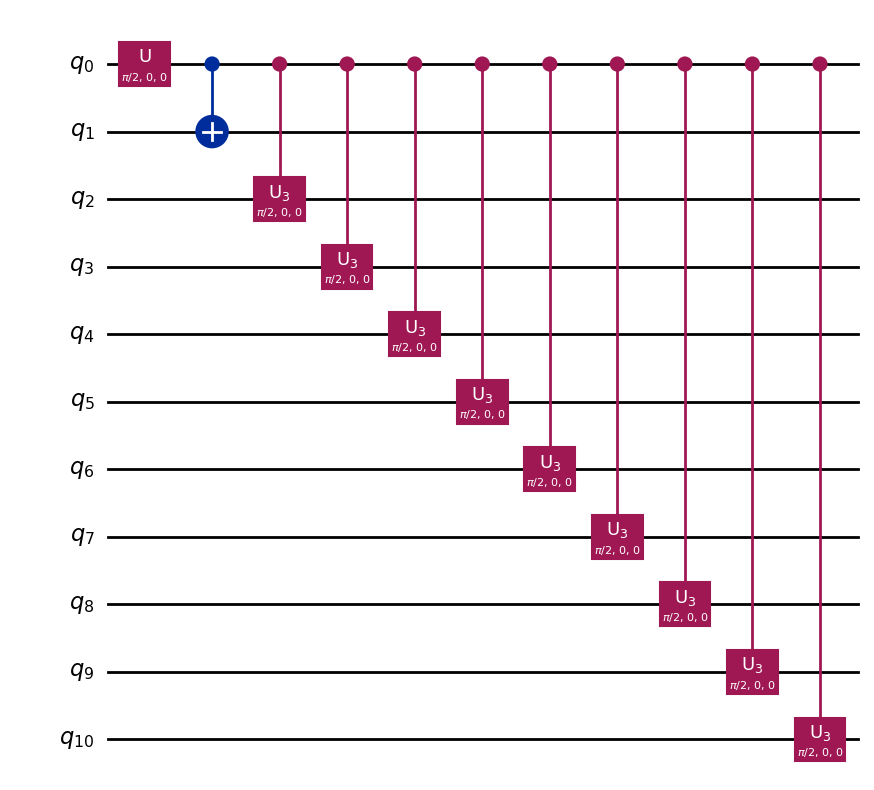

In [ ]:
# Quantum mutual information: system + observer + environment pi/2 

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import pandas as pd

os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

%matplotlib inline

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Built the quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit (Friend)
        qb_envir = list(range(2, self.n)) # environment qubits
        
        qc.u(self.theta, self.phi, 0, qb_sys)
        qc.cx(qb_sys, qb_obser)
        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        """keep_qubits = qubits MUỐN GIỮ LẠI, tự động tính trace_out"""
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  # NumPy array cho VNE

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    
    def holevo_info(self, rho_S, rho_SE):
        H_S = self.VNE(rho_S)
        H_SE = self.VNE(rho_SE)
        H_E = self.VNE(partial_trace(DensityMatrix(rho_SE.data), [0]))  # trace out S
        return H_S - (H_SE - H_E)

# ========== MAIN SIMULATION ==========
numQubits = 11
theta, phi = np.pi/2, 0  # |+> 
qc = QCircuit(theta, phi, numQubits)
rho_total = qc.DensityMatrix()
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*50)

# ========== 1. QMI(S : Observer/Friend) ==========
rho_S    = qc.get_reduced_dm([0])         # System q0 
rho_Obs  = qc.get_reduced_dm([1])         # Observer q1 
rho_SObs = qc.get_reduced_dm([0,1])       # S+Observer 
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# ========== 2. QMI(S : Environment fragments) ==========
env_qubits = list(range(2, numQubits))  # q2..q10
results_S_Envir = []
redundancy_points = []


for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  # Fragment [q2], [q2,q3], ...
    rho_Ef   = qc.get_reduced_dm(Ef)     # Fragment state 
    rho_SEf  = qc.get_reduced_dm([0]+Ef) # System + fragment 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Redundancy test
    H_S = QI_calc.VNE(rho_S)
    is_redundant = QMI_S_Ef >= 0.9 * H_S
    redundancy_points.append(is_redundant)

# ========== 3. FULL Environment (để thấy 2H(S)) ==========
rho_E_full  = qc.get_reduced_dm(env_qubits)      # Toàn bộ env q2..q10
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  # S + full env
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# ========== QMI plot ==========
plt.figure(figsize=(8,7))


fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

fs_ext = np.concatenate([[0], fs])                
results_ext = np.concatenate([[0.0], results_S_Envir])  # I(0)=0

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_fragment) - plateau {max(results_S_Envir):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env qubits)', fontsize=13)
plt.ylabel('Quantum Mutual Information I(S:F) [bits]', fontsize=13)
plt.title('Quantum Darwinism: Redundancy Plateau', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.xlim(0, 105)
plt.ylim(0, max(QMI_S_Efull*1.1, 2.1))
plt.tight_layout()
plt.show()
plt.clf() 
# ========== RESULTS ==========
H_S = QI_calc.VNE(rho_S)
print(f"\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits ({QMI_S_Obs/H_S*100:.1f}% of H(S))")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits ({QMI_S_Efull/H_S*100:.1f}% of 2H(S))")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
#print(f"Redundancy starts = fragment #{next(i+1 for i,r in enumerate(redundancy_points) if r)}/9")

# === Quantum Circuit plot ===
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

#=== Save Data ===
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}

with open('quantum_darwinism_sys_envir_obs_pi2_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)




Quantum Darwinism Simulation (n=11 qubits)


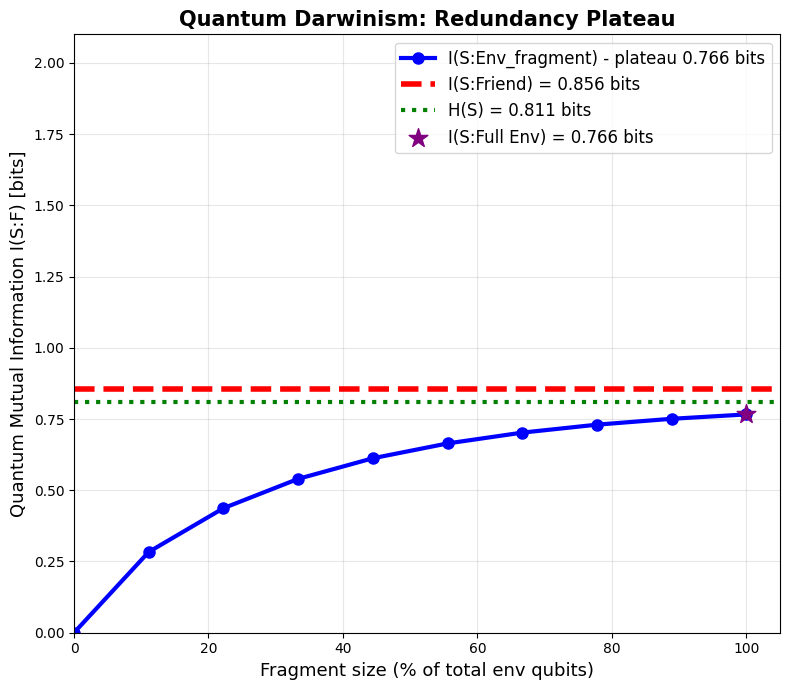


RESULTS:
H(S)              = 0.811 bits
I(S:Friend)       = 0.856 bits (105.6% of H(S))
I(S:Full Env)     = 0.766 bits (94.4% of 2H(S))
Max fragment I    = 0.766 bits
Redundancy starts = fragment #8/9


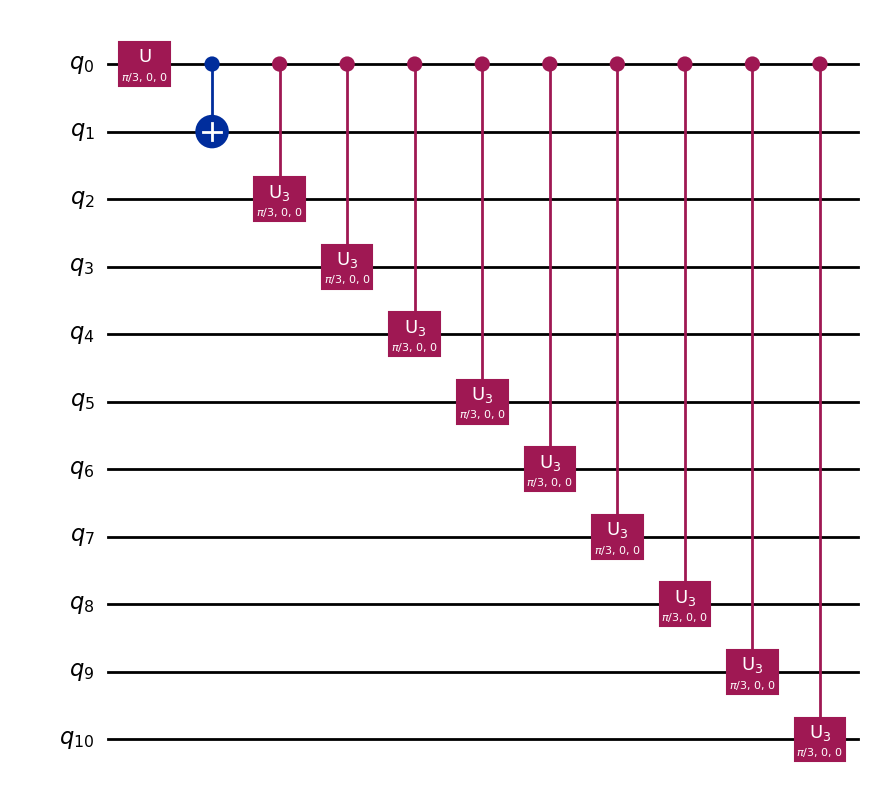

In [ ]:
# Quantum mutual information: system + observer + environment pi/3

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")
%matplotlib inline

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Built the quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit
        qb_envir = list(range(2, self.n)) # environment qubits
        
        qc.u(self.theta, self.phi, 0, qb_sys)
        qc.cx(qb_sys, qb_obser)
        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        """keep_qubits = qubits MUỐN GIỮ LẠI, tự động tính trace_out"""
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  # NumPy array cho VNE

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE

# ========== MAIN SIMULATION ==========
numQubits = 11
theta, phi = np.pi/3, 0  # |+> 
qc = QCircuit(theta, phi, numQubits)
rho_total = qc.DensityMatrix()
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*50)

# ========== 1. QMI(S : Observer/Friend) ==========
rho_S    = qc.get_reduced_dm([0])         # System q0 
rho_Obs  = qc.get_reduced_dm([1])         # Observer q1 
rho_SObs = qc.get_reduced_dm([0,1])       # S+Observer 
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# ========== 2. QMI(S : Environment fragments) ==========
env_qubits = list(range(2, numQubits))  # q2..q10
results_S_Envir = []
redundancy_points = []


for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  # Fragment [q2], [q2,q3], ...
    rho_Ef   = qc.get_reduced_dm(Ef)     # Fragment state 
    rho_SEf  = qc.get_reduced_dm([0]+Ef) # System + fragment 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Redundancy test
    H_S = QI_calc.VNE(rho_S)
    is_redundant = QMI_S_Ef >= 0.9 * H_S
    redundancy_points.append(is_redundant)

# ========== 3. FULL Environment (để thấy 2H(S)) ==========
rho_E_full  = qc.get_reduced_dm(env_qubits)      # Toàn bộ env q2..q10
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  # S + full env
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# ========== QMI plot ==========
plt.figure(figsize=(8,7))


fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

fs_ext = np.concatenate([[0], fs])                
results_ext = np.concatenate([[0.0], results_S_Envir])  # I(0)=0

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_fragment) - plateau {max(results_S_Envir):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env qubits)', fontsize=13)
plt.ylabel('Quantum Mutual Information I(S:F) [bits]', fontsize=13)
plt.title('Quantum Darwinism: Redundancy Plateau', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.xlim(0, 105)
plt.ylim(0, max(QMI_S_Efull*1.1, 2.1))
plt.tight_layout()
plt.show()

# ========== RESULTS ==========
H_S = QI_calc.VNE(rho_S)
print(f"\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits ({QMI_S_Obs/H_S*100:.1f}% of H(S))")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits ({QMI_S_Efull/H_S*100:.1f}% of 2H(S))")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
print(f"Redundancy starts = fragment #{next(i+1 for i,r in enumerate(redundancy_points) if r)}/9")

# === Quantum Circuit plot ===
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

# === Save Data ===
import pickle

data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi,
    'label': 'pi_over_3'  # Để phân biệt với π/2
}

with open('quantum_darwinism_sys_envir_obs_pi3_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

🔬 Quantum Darwinism: System↔Environment ONLY (n=11 qubits)


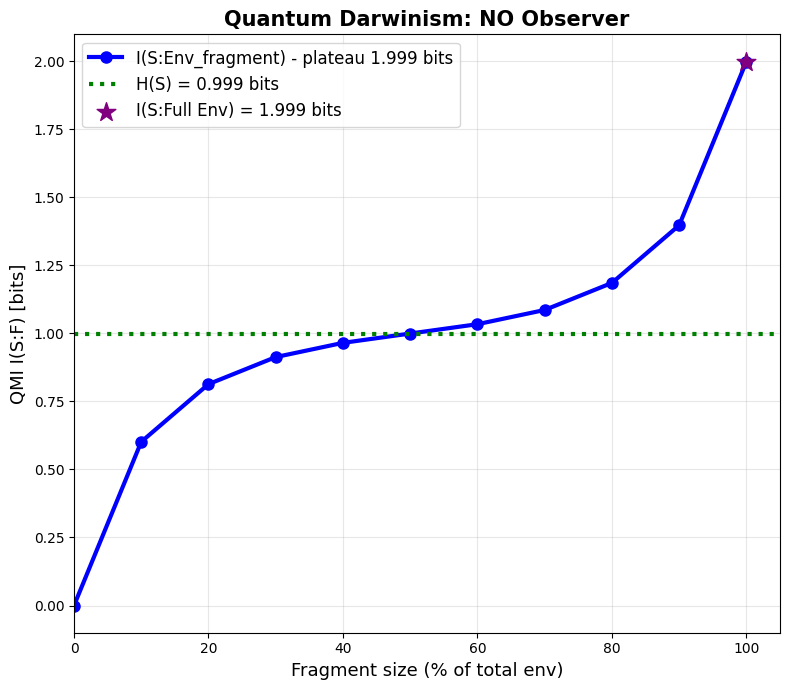

✅ Plot 1: QMI curve hoàn thành!


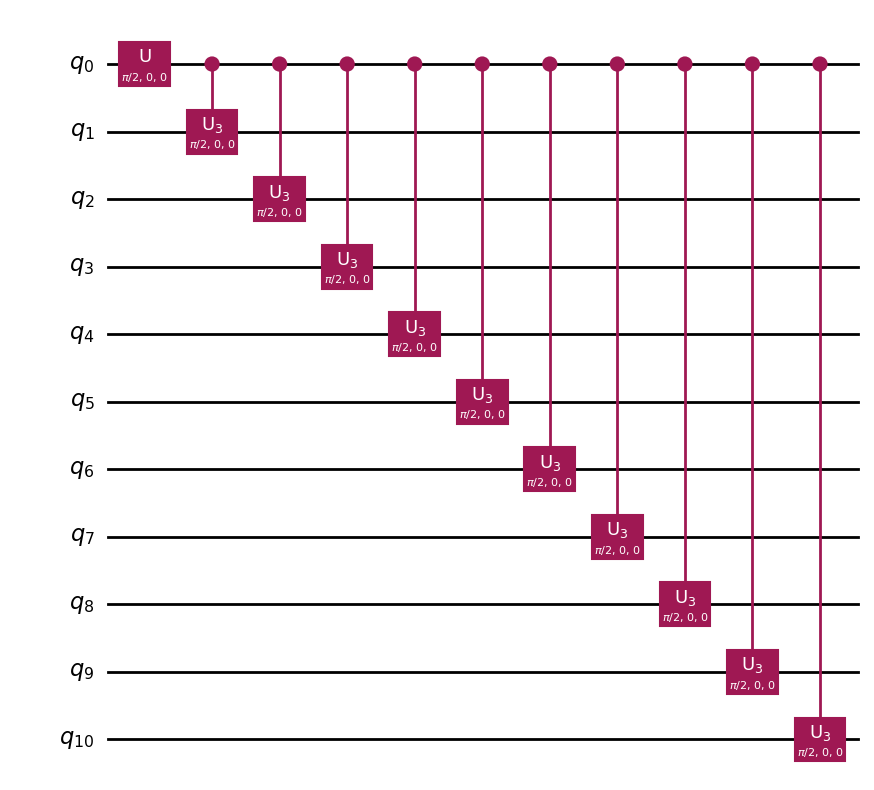

In [ ]:
# Quantum mutual information: system + environment - no obsever pi/2
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")
%matplotlib inline

class QCircuit:     
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # ✅ BỎ HẲN OBSERVER - chỉ System + Environment
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit (q0)
        qb_envir = list(range(1, self.n)) # environment qubits (q1..q10)
        
        # System prepare |+> state
        qc.u(self.theta, self.phi, 0, qb_sys)
        
        # 🔥 Environment nối TRỰC TIẾP với System (không có observer)
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])  # control=q0, target=env_i
        
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
     
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data
         

class QuantumInformation(): 
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def quantum_discord(self, reduced_SE, reduced_S):
        conditional_entropies = []
        mutual_information = self.mutual_information(reduced_S, reduced_SE)  # Calculate mutual information
        for projector in np.linalg.eigh(reduced_S)[1]:
            proj = projector.data
            p_A_i = np.trace((proj @ reduced_SE) @ proj)
            if p_A_i > 0:
                reduced_SE_i = (proj @ reduced_SE @ proj) / p_A_i
                rho_B_i = partial_trace(DensityMatrix(reduced_SE_i), [0]).data
                conditional_entropies.append(p_A_i * self.VNE(rho_B_i))
        # Consider mutual information or alternative redundancy measure
        total_discord = np.sum(conditional_entropies) - mutual_information
        return total_discord
    
# ========== RUN SIMULATION ==========
numQubits = 11  # q0=system, q1..q10=env (bỏ observer)
theta, phi = np.pi/2, 0  # |+> state
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

print(f"🔬 Quantum Darwinism: System↔Environment ONLY (n={numQubits} qubits)")
print("="*60)

# 1. System state
rho_S = qc.get_reduced_dm([0])         

# 2. QMI(S:Environment fragments)
env_qubits = list(range(1, numQubits))  # q1..q10
results_S_Envir = []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  
    rho_Ef   = qc.get_reduced_dm(Ef)     
    rho_SEf  = qc.get_reduced_dm([0]+Ef) 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)

# 3. Full Environment
rho_E_full  = qc.get_reduced_dm(env_qubits)      
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# ========== PLOT + CIRCUIT ==========
# ========== PLOT 1: QMI CURVE RIÊNG ==========
plt.figure(figsize=(8,7))

fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100
fs_ext = np.concatenate([[0], fs])                 
results_ext = np.concatenate([[0.0], results_S_Envir])  

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_fragment) - plateau {max(results_S_Envir):.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')
plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env)', fontsize=13)
plt.ylabel('QMI I(S:F) [bits]', fontsize=13)
plt.title('Quantum Darwinism: NO Observer', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

print("✅ Plot 1: QMI curve hoàn thành!")

# ========== PLOT 2: CIRCUIT DIAGRAM RIÊNG ==========
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

# ========== RESULTS ==========
H_S = QI_calc.VNE(rho_S)


data_no_observer = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi,
    'setup': 'no_observer_pi2',  # Để phân biệt
    'env_qubits_start': 1  # q1..q10 (khác với q2..q10)
}

with open('quantum_darwinism_no_observer_pi2_data.pkl', 'wb') as f:
    pickle.dump(data_no_observer, f)

Quantum Darwinism Simulation (n=11 qubits)


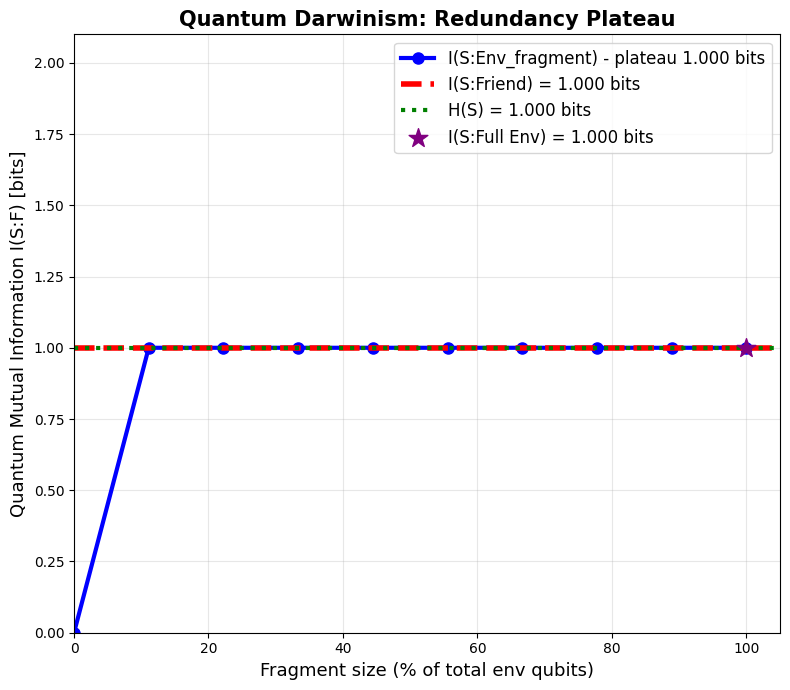


RESULTS:
H(S)              = 1.000 bits
I(S:Friend)       = 1.000 bits (100.0% of H(S))
I(S:Full Env)     = 1.000 bits (100.0% of 2H(S))
Max fragment I    = 1.000 bits
Redundancy starts = fragment #1/9


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


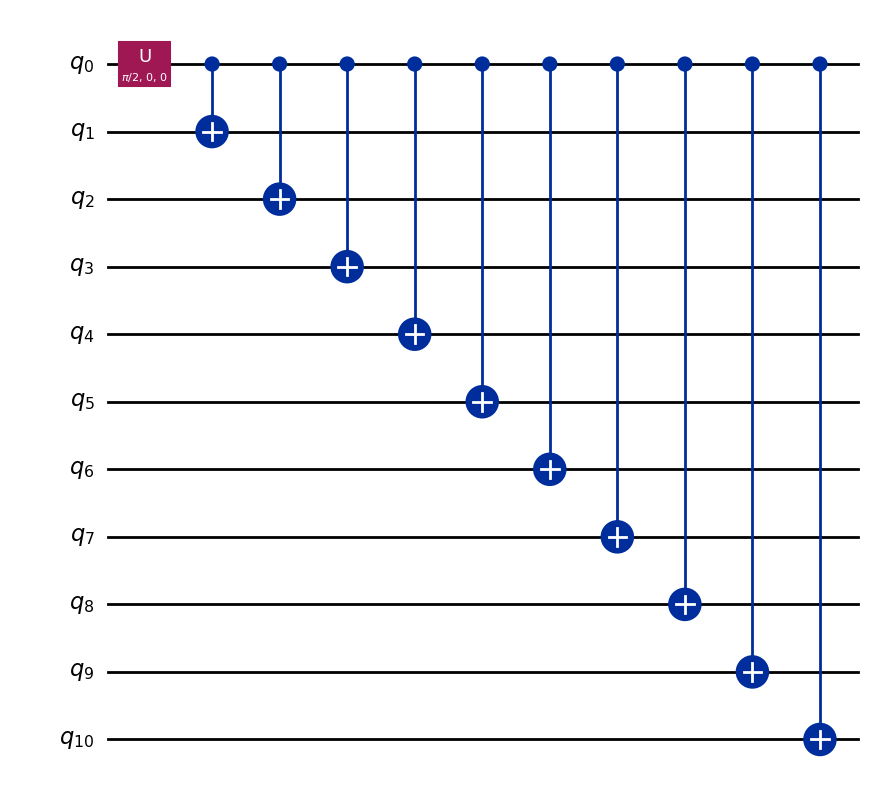

In [ ]:
# Quantum mutual information: system + observer + environment + CNOT

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self):  # Build the quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0  # system qubit
        qb_obser = 1  # observer qubit
        qb_envir = list(range(2, self.n))  # environment qubits

        # Giữ lại U3 cho qubit hệ thống
        qc.u(self.theta, self.phi, 0, qb_sys)

        # CNOT giữa hệ thống và qubit quan sát
        qc.cx(qb_sys, qb_obser)

        # Thay controlled-U3 bằng CNOT cho các qubit môi trường
        for i in qb_envir:
            qc.cx(qb_sys, i)

        return qc

    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        """keep_qubits = qubits MUỐN GIỮ LẠI, tự động tính trace_out"""
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  # NumPy array cho VNE

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE

# ========== MAIN SIMULATION ==========
numQubits = 11
theta, phi = np.pi/2, 0  # |+> 
qc = QCircuit(theta, phi, numQubits)
rho_total = qc.DensityMatrix()
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*50)

# ========== 1. QMI(S : Observer/Friend) ==========
rho_S    = qc.get_reduced_dm([0])         # System q0 
rho_Obs  = qc.get_reduced_dm([1])         # Observer q1 
rho_SObs = qc.get_reduced_dm([0,1])       # S+Observer 
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# ========== 2. QMI(S : Environment fragments) ==========
env_qubits = list(range(2, numQubits))  # q2..q10
results_S_Envir = []
redundancy_points = []


for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  # Fragment [q2], [q2,q3], ...
    rho_Ef   = qc.get_reduced_dm(Ef)     # Fragment state 
    rho_SEf  = qc.get_reduced_dm([0]+Ef) # System + fragment 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Redundancy test
    H_S = QI_calc.VNE(rho_S)
    is_redundant = QMI_S_Ef >= 0.9 * H_S
    redundancy_points.append(is_redundant)

# ========== 3. FULL Environment (để thấy 2H(S)) ==========
rho_E_full  = qc.get_reduced_dm(env_qubits)      # Toàn bộ env q2..q10
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  # S + full env
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# ========== QMI plot ==========
plt.figure(figsize=(8,7))


fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

fs_ext = np.concatenate([[0], fs])                
results_ext = np.concatenate([[0.0], results_S_Envir])  # I(0)=0

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_fragment) - plateau {max(results_S_Envir):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env qubits)', fontsize=13)
plt.ylabel('Quantum Mutual Information I(S:F) [bits]', fontsize=13)
plt.title('Quantum Darwinism: Redundancy Plateau', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.xlim(0, 105)
plt.ylim(0, max(QMI_S_Efull*1.1, 2.1))
plt.tight_layout()
plt.show()

# ========== RESULTS ==========
H_S = QI_calc.VNE(rho_S)
print(f"\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits ({QMI_S_Obs/H_S*100:.1f}% of H(S))")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits ({QMI_S_Efull/H_S*100:.1f}% of 2H(S))")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
print(f"Redundancy starts = fragment #{next(i+1 for i,r in enumerate(redundancy_points) if r)}/9")

# === Quantum Circuit plot ===
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

#=== Save Data ===
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}

with open('quantum_darwinism_sys_envir_obs_CNOT_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)


Random theta_env (seed=42): [0.58832624 1.49337854 1.1498134  0.94037055 0.24507351]...


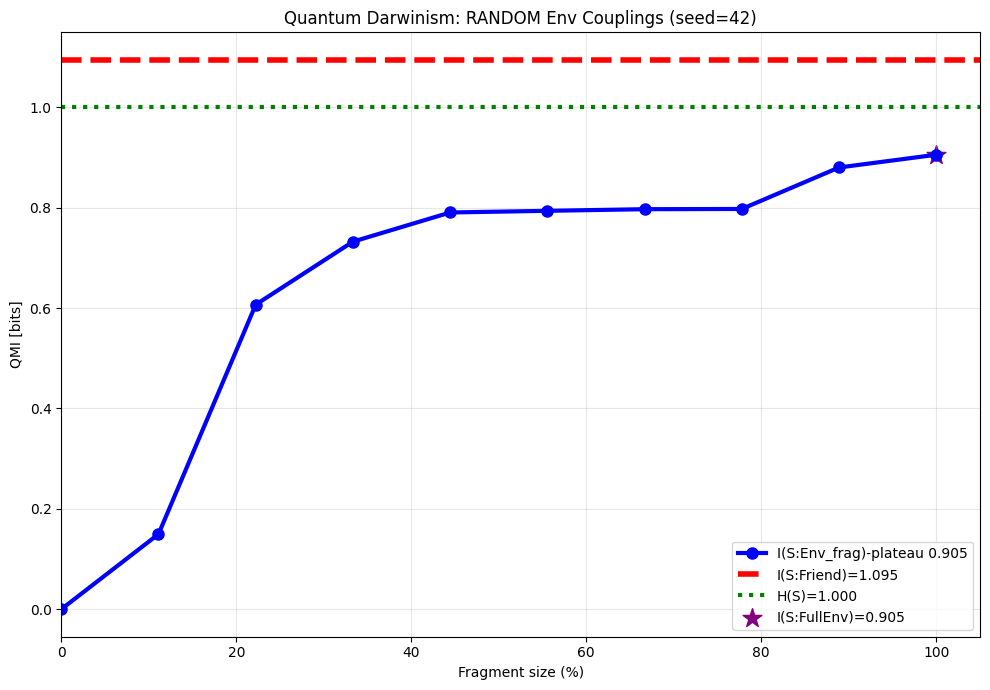


RESULTS (RANDOM θ_env, seed=42):
H(S)              = 1.000 bits
I(S:Friend)       = 1.095 bits
I(S:Full Env)     = 0.905 bits
Max fragment I    = 0.905 bits


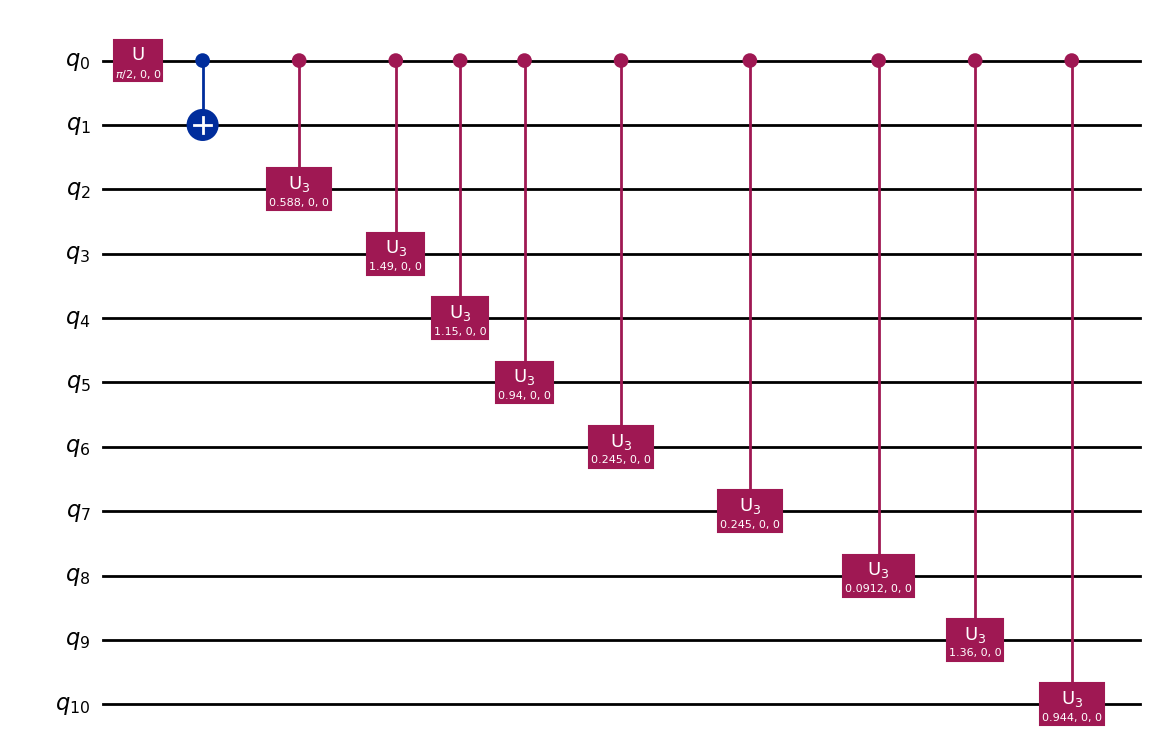

In [ ]:
# Quantum mutual information: system + obsever + envir + random interaction
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")
%matplotlib inline

class QCircuit:    
    def __init__(self, theta_sys, phi_sys, n, seed=42):  
        self.theta_sys = theta_sys   
        self.phi_sys = phi_sys       
        self.n = n           
        self.seed = seed
        np.random.seed(seed)
        
        # RANDOM THETA cho TỪNG env qubit [0, π/2]
        self.theta_env = np.random.uniform(0, np.pi/2, n-2)
        print(f"Random theta_env (seed={seed}): {self.theta_env[:5]}...")

    def Circuit(self):
        qc = QuantumCircuit(self.n)
        qb_sys, qb_obser = 0, 1 
        qb_envir = list(range(2, self.n)) 
        
        # System + observer (giữ nguyên)
        qc.u(self.theta_sys, self.phi_sys, 0, qb_sys)
        qc.cx(qb_sys, qb_obser)
        
        # RANDOM couplings với env
        for i, theta_i in enumerate(self.theta_env):
            cu_gate = U3Gate(theta_i, self.phi_sys, 0).control(1)
            qc.append(cu_gate, [qb_sys, qb_envir[i]])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        return self.VNE(S_State) + self.VNE(E_State) - self.VNE(SE_State)

# ========== RUN ==========
numQubits = 11
qc_random = QCircuit(np.pi/2, 0, numQubits, seed=42)
QI_calc = QuantumInformation()

# Calculations (giữ nguyên logic cũ)
env_qubits = list(range(2, numQubits))
rho_S = qc_random.get_reduced_dm([0])
rho_Obs = qc_random.get_reduced_dm([1])
rho_SObs = qc_random.get_reduced_dm([0,1])
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

results_S_Envir = []
for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef = qc_random.get_reduced_dm(Ef)
    rho_SEf = qc_random.get_reduced_dm([0]+Ef)
    results_S_Envir.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))

rho_E_full = qc_random.get_reduced_dm(env_qubits)
rho_SE_full = qc_random.get_reduced_dm([0]+env_qubits)
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# Plot
plt.figure(figsize=(10,7))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100
fs_ext = np.concatenate([[0], fs])
results_ext = np.concatenate([[0.0], results_S_Envir])

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_frag)-plateau {max(results_S_Envir):.3f}')
plt.axhline(QMI_S_Obs, color='r', lw=4, ls='--', label=f'I(S:Friend)={QMI_S_Obs:.3f}')
plt.axhline(QI_calc.VNE(rho_S), color='g', lw=3, ls=':', label=f'H(S)={QI_calc.VNE(rho_S):.3f}')
plt.scatter(100, QMI_S_Efull, c='purple', s=200, marker='*', label=f'I(S:FullEnv)={QMI_S_Efull:.3f}')

plt.xlabel('Fragment size (%)'); plt.ylabel('QMI [bits]')
plt.title('Quantum Darwinism: RANDOM Env Couplings (seed=42)')
plt.legend(); plt.grid(alpha=0.3); plt.xlim(0,105)
plt.tight_layout(); plt.show()

# Results
H_S = QI_calc.VNE(rho_S)
print(f"\nRESULTS (RANDOM θ_env, seed=42):")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")

qc_random.Circuit().draw(output='mpl', style='iqx')
plt.show()

#=== Save Data ===
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}

with open('quantum_darwinism_sys_envir_obs_random_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

In [ ]:
# Quantum mutual information + Holevo information: system + observer + environment pi/2 

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import pandas as pd

os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

%matplotlib inline

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Built the quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit (Friend)
        qb_envir = list(range(2, self.n)) # environment qubits
        
        qc.u(self.theta, self.phi, 0, qb_sys)
        qc.cx(qb_sys, qb_obser)
        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        """keep_qubits = qubits MUỐN GIỮ LẠI, tự động tính trace_out"""
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  # NumPy array cho VNE

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    
    def holevo_info(self, rho_S, rho_SE):
        H_S = self.VNE(rho_S)
        H_SE = self.VNE(rho_SE)
        H_E = self.VNE(partial_trace(DensityMatrix(rho_SE.data), [0]))  # trace out S
        return H_S - (H_SE - H_E)

# ========== MAIN SIMULATION ==========
numQubits = 11
theta, phi = np.pi/2, 0  # |+> 
qc = QCircuit(theta, phi, numQubits)
rho_total = qc.DensityMatrix()
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*50)

# ========== 1. QMI(S : Observer/Friend) ==========
rho_S    = qc.get_reduced_dm([0])         # System q0 
rho_Obs  = qc.get_reduced_dm([1])         # Observer q1 
rho_SObs = qc.get_reduced_dm([0,1])       # S+Observer 
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# ========== 2. QMI(S : Environment fragments) ==========
env_qubits = list(range(2, numQubits))  # q2..q10
results_S_Envir = []
redundancy_points = []


for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  # Fragment [q2], [q2,q3], ...
    rho_Ef   = qc.get_reduced_dm(Ef)     # Fragment state 
    rho_SEf  = qc.get_reduced_dm([0]+Ef) # System + fragment 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Redundancy test
    H_S = QI_calc.VNE(rho_S)
    is_redundant = QMI_S_Ef >= 0.9 * H_S
    redundancy_points.append(is_redundant)

# ========== 3. FULL Environment (để thấy 2H(S)) ==========
rho_E_full  = qc.get_reduced_dm(env_qubits)      # Toàn bộ env q2..q10
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  # S + full env
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# ========== QMI plot ==========
plt.figure(figsize=(8,7))


fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

fs_ext = np.concatenate([[0], fs])                
results_ext = np.concatenate([[0.0], results_S_Envir])  # I(0)=0

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_fragment) - plateau {max(results_S_Envir):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env qubits)', fontsize=13)
plt.ylabel('Quantum Mutual Information I(S:F) [bits]', fontsize=13)
plt.title('Quantum Darwinism: Redundancy Plateau', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.xlim(0, 105)
plt.ylim(0, max(QMI_S_Efull*1.1, 2.1))
plt.tight_layout()
plt.show()
plt.clf() 
# ========== RESULTS ==========
H_S = QI_calc.VNE(rho_S)
print(f"\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits ({QMI_S_Obs/H_S*100:.1f}% of H(S))")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits ({QMI_S_Efull/H_S*100:.1f}% of 2H(S))")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
#print(f"Redundancy starts = fragment #{next(i+1 for i,r in enumerate(redundancy_points) if r)}/9")

# === Quantum Circuit plot ===
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

#=== Save Data ===
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}

with open('quantum_darwinism_sys_envir_obs_pi2_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)




Quantum Darwinism Simulation (n=11 qubits)


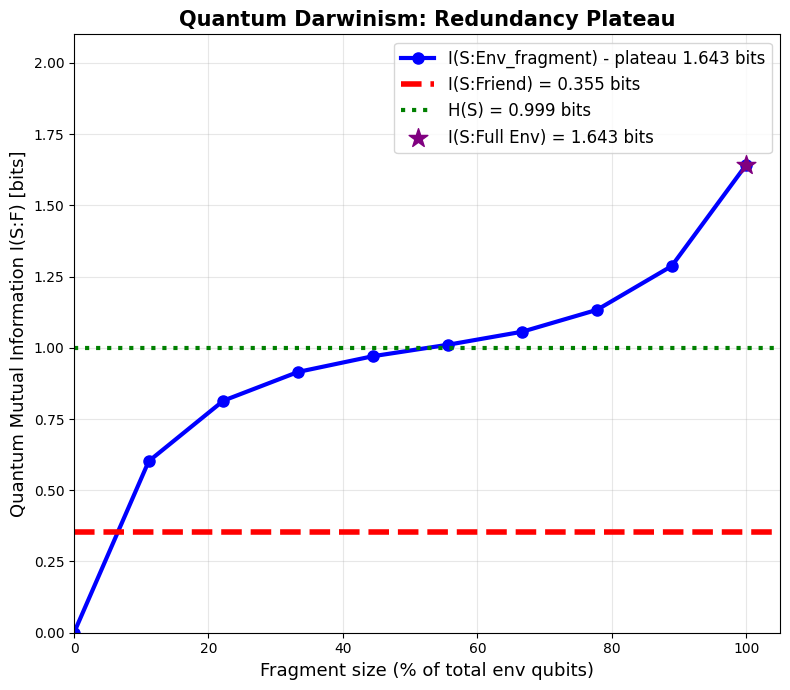


RESULTS:
H(S)              = 0.999 bits
I(S:Friend)       = 0.355 bits (35.5% of H(S))
I(S:Full Env)     = 1.643 bits (164.5% of 2H(S))
Max fragment I    = 1.643 bits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


<Figure size 640x480 with 0 Axes>

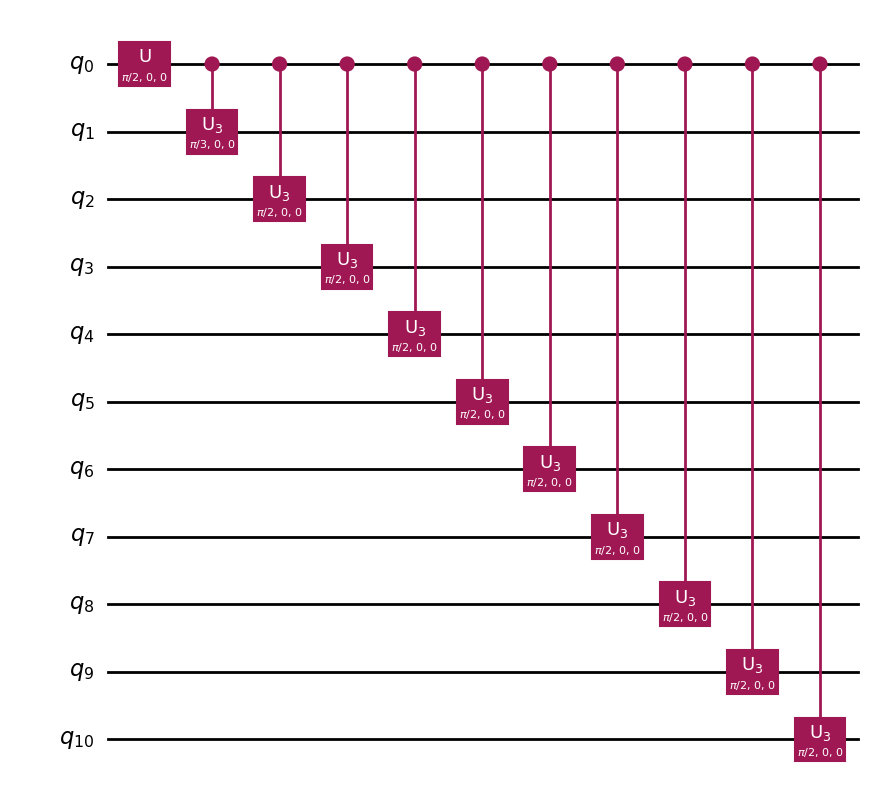

In [3]:
# Quantum mutual information: system + observer + environment pi/2 | obsever interaction: π/3

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import pandas as pd

os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

%matplotlib inline

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Built the quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit (Friend)
        qb_envir = list(range(2, self.n)) # environment qubits
        
        qc.u(self.theta, self.phi, 0, qb_sys)
        # Controlled-U(pi/3) từ q0 (system) sang q1 (observer)
        u_gate = U3Gate(np.pi/3, 0, 0).control(1)
        qc.append(u_gate, [qb_sys, qb_obser])

        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        """keep_qubits = qubits MUỐN GIỮ LẠI, tự động tính trace_out"""
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  # NumPy array cho VNE

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    
    def holevo_info(self, rho_S, rho_SE):
        H_S = self.VNE(rho_S)
        H_SE = self.VNE(rho_SE)
        H_E = self.VNE(partial_trace(DensityMatrix(rho_SE.data), [0]))  # trace out S
        return H_S - (H_SE - H_E)

# ========== MAIN SIMULATION ==========
numQubits = 11
theta, phi = np.pi/2, 0  # |+> 
qc = QCircuit(theta, phi, numQubits)
rho_total = qc.DensityMatrix()
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*50)

# ========== 1. QMI(S : Observer/Friend) ==========
rho_S    = qc.get_reduced_dm([0])         # System q0 
rho_Obs  = qc.get_reduced_dm([1])         # Observer q1 
rho_SObs = qc.get_reduced_dm([0,1])       # S+Observer 
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# ========== 2. QMI(S : Environment fragments) ==========
env_qubits = list(range(2, numQubits))  # q2..q10
results_S_Envir = []
redundancy_points = []


for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  # Fragment [q2], [q2,q3], ...
    rho_Ef   = qc.get_reduced_dm(Ef)     # Fragment state 
    rho_SEf  = qc.get_reduced_dm([0]+Ef) # System + fragment 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Redundancy test
    H_S = QI_calc.VNE(rho_S)
    is_redundant = QMI_S_Ef >= 0.9 * H_S
    redundancy_points.append(is_redundant)

# ========== 3. FULL Environment (để thấy 2H(S)) ==========
rho_E_full  = qc.get_reduced_dm(env_qubits)      # Toàn bộ env q2..q10
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  # S + full env
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# ========== QMI plot ==========
plt.figure(figsize=(8,7))


fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

fs_ext = np.concatenate([[0], fs])                
results_ext = np.concatenate([[0.0], results_S_Envir])  # I(0)=0

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_fragment) - plateau {max(results_S_Envir):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env qubits)', fontsize=13)
plt.ylabel('Quantum Mutual Information I(S:F) [bits]', fontsize=13)
plt.title('Quantum Darwinism: Redundancy Plateau', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.xlim(0, 105)
plt.ylim(0, max(QMI_S_Efull*1.1, 2.1))
plt.tight_layout()
plt.show()
plt.clf() 
# ========== RESULTS ==========
H_S = QI_calc.VNE(rho_S)
print(f"\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits ({QMI_S_Obs/H_S*100:.1f}% of H(S))")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits ({QMI_S_Efull/H_S*100:.1f}% of 2H(S))")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
#print(f"Redundancy starts = fragment #{next(i+1 for i,r in enumerate(redundancy_points) if r)}/9")

# === Quantum Circuit plot ===
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

#=== Save Data ===
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}

with open('quantum_darwinism_sys_envir_obs_pi2_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)




**QMI comparision by varying quantum gates**


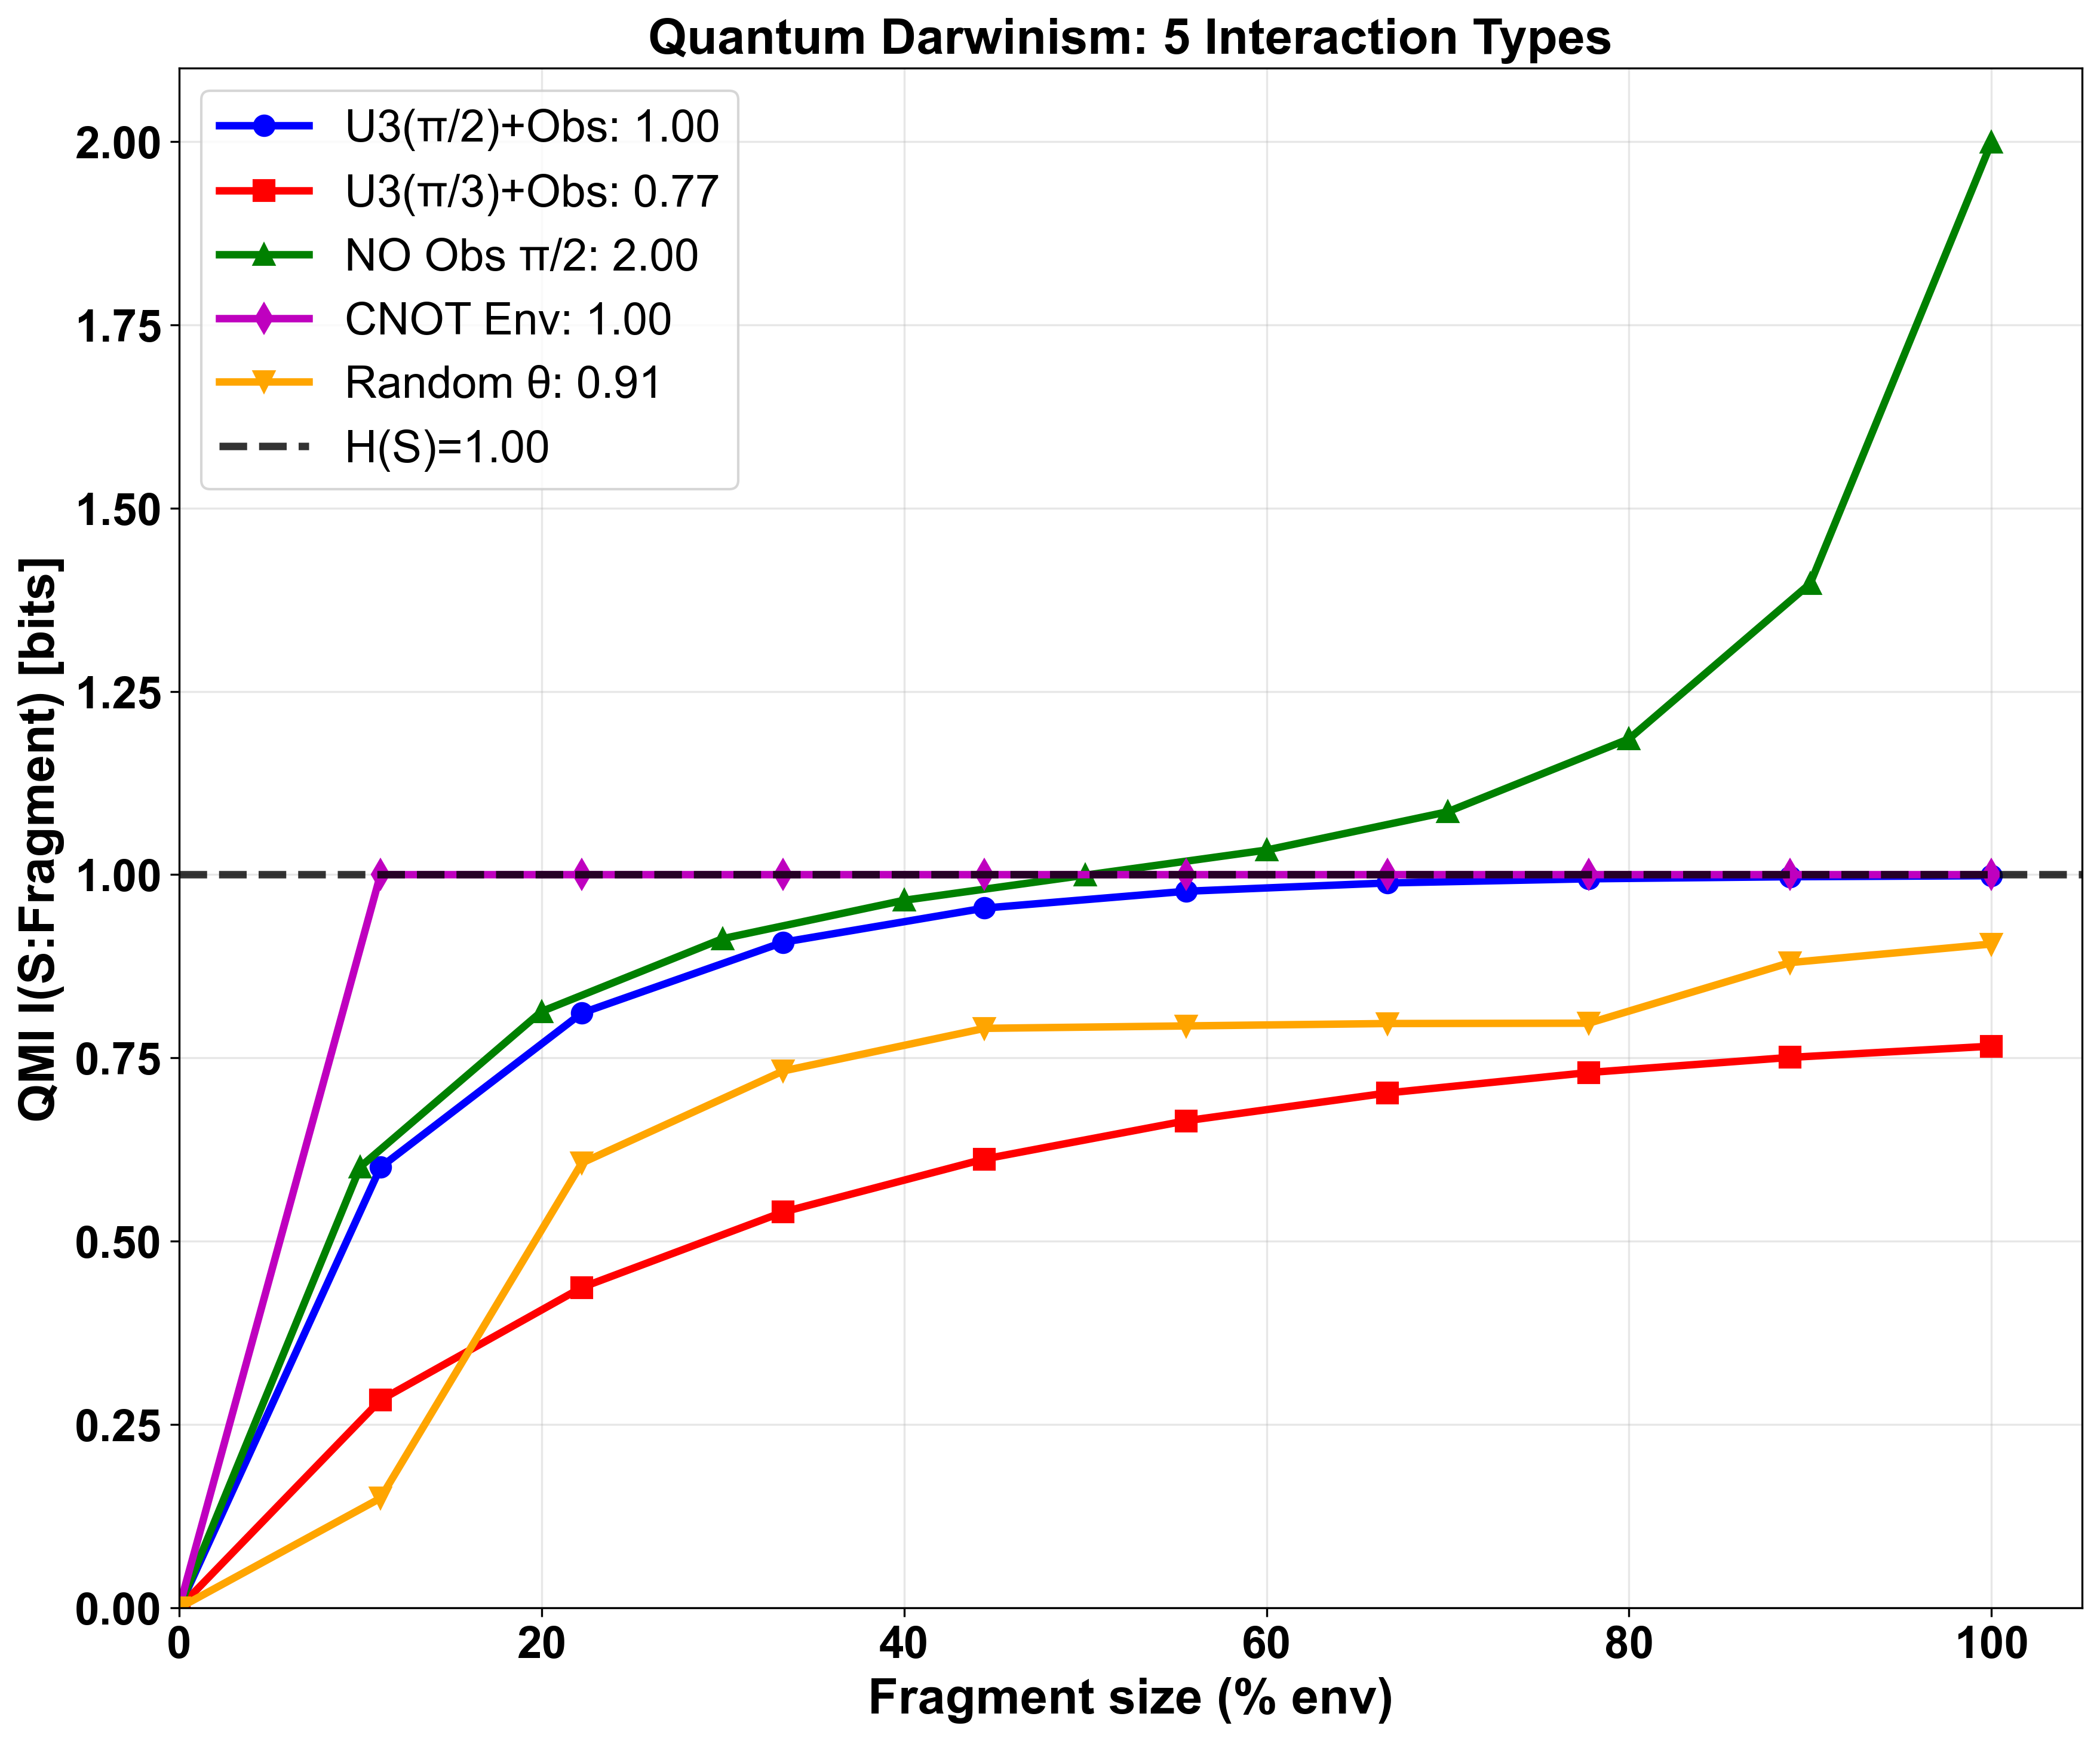


ALL INTERACTIONS COMPARISON
Setup              H(S)   Max I(S:f) I(FullEnv) Plateau
------------------------------------------------------------------------------------------
U3(π/2)+Obs        1.000  0.999     0.999      Sharp
U3(π/3)+Obs        0.811  0.766     0.766      Gradual
NO Obs             0.999  1.999     1.999      Sharp
CNOT               1.000  1.000     1.000      Sharp
Random             1.000  0.905     0.905      Gradual


In [ ]:
# Quantum mutual information plot comparison: 5 interaction types (pi/2, pi/3, no observer, CNOT, random)

import pickle
import matplotlib.pyplot as plt
import os
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

plt.rcParams.update({
    'font.family': 'Arial',           # Arial cho tất cả text
    'font.size': 16,
    'axes.labelsize': 20,
    'axes.titlesize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'lines.linewidth': 3,
    'lines.markersize': 8
})

def load_and_compare_all_five():
    # Load 5 datasets RIÊNG BIỆT
    with open('quantum_darwinism_sys_envir_obs_pi2_data.pkl', 'rb') as f:
        obs_pi2 = pickle.load(f)
    
    with open('quantum_darwinism_sys_envir_obs_pi3_data.pkl', 'rb') as f:
        obs_pi3 = pickle.load(f)
    
    with open('quantum_darwinism_no_observer_pi2_data.pkl', 'rb') as f:  # ← Tên đúng
        no_obs_pi2 = pickle.load(f)
    
    with open('quantum_darwinism_sys_envir_obs_CNOT_data.pkl', 'rb') as f:
        cnot_data = pickle.load(f)
    
    with open('quantum_darwinism_sys_envir_obs_random_data.pkl', 'rb') as f:
        random_data = pickle.load(f)
    
    # PLOT 5 ĐƯỜNG
    plt.figure(figsize=(12,10))
    
    plt.plot(obs_pi2['fs_ext'], obs_pi2['results_ext'], 'b-o', lw=3, ms=8,
             label=f'U3(π/2)+Obs: {max(obs_pi2["results_S_Envir"]):.2f}')
    plt.plot(obs_pi3['fs_ext'], obs_pi3['results_ext'], 'r-s', lw=3, ms=8,
             label=f'U3(π/3)+Obs: {max(obs_pi3["results_S_Envir"]):.2f}')
    plt.plot(no_obs_pi2['fs_ext'], no_obs_pi2['results_ext'], 'g-^', lw=3, ms=8,
             label=f'NO Obs π/2: {max(no_obs_pi2["results_S_Envir"]):.2f}')
    plt.plot(cnot_data['fs_ext'], cnot_data['results_ext'], 'm-d', lw=3, ms=8,
             label=f'CNOT Env: {max(cnot_data["results_S_Envir"]):.2f}')
    plt.plot(random_data['fs_ext'], random_data['results_ext'], 'orange', marker='v', lw=3, ms=8,
             label=f'Random θ: {max(random_data["results_S_Envir"]):.2f}')
    
    plt.axhline(obs_pi2['H_S'], color='k', lw=3, ls='--', alpha=0.8, 
                label=f'H(S)={obs_pi2["H_S"]:.2f}')
    
    plt.xlabel('Fragment size (% env)', fontsize=20, fontweight='bold')
    plt.ylabel('QMI I(S:Fragment) [bits]', fontsize=20, fontweight='bold')
    plt.title('Quantum Darwinism: 5 Interaction Types', fontsize=20, fontweight='bold')
    plt.legend(fontsize=18); plt.grid(True, alpha=0.3)
    plt.xlim(0, 105); plt.ylim(0, 2.1)
    plt.tick_params(axis='both', labelsize=18)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontweight('bold')
    plt.tight_layout(); plt.show()
    
    # TABLE 5 cột
    print("\n" + "="*90)
    print("ALL INTERACTIONS COMPARISON")
    print(f"{'Setup':<18} {'H(S)':<6} {'Max I(S:f)':<9} {'I(FullEnv)':<10} {'Plateau'}")
    print("-"*90)
    setups = [
        (obs_pi2, 'U3(π/2)+Obs'), (obs_pi3, 'U3(π/3)+Obs'), 
        (no_obs_pi2, 'NO Obs'), (cnot_data, 'CNOT'), (random_data, 'Random')
    ]
    for data, name in setups:
        print(f"{name:<18} {data['H_S']:<6.3f} {max(data['results_S_Envir']):<9.3f} {data['QMI_S_Efull']:<10.3f} {'Sharp' if max(data['results_S_Envir'])>0.95 else 'Gradual'}")

# Chạy
load_and_compare_all_five()

**QMI 3D simulation by varying theta, and environment fragments**
- Two model:
    - No obsever
    - With obsever
---

In [ ]:
# Quantum Darwinism 3D Simulation (Sys + Obs + Envir)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import os
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

# ================== Classes ==================
class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Build quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit
        qb_envir = list(range(2, self.n)) # environment qubits
        
        qc.u(self.theta, self.phi, 0, qb_sys)
        qc.cx(qb_sys, qb_obser)
        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE

# ================== Helper Function ==================
def compute_qmi(theta, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, 0, numQubits)
    rho_S = qc.get_reduced_dm([0])
    qmi_vals = []
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        rho_Ef   = qc.get_reduced_dm(Ef)
        rho_SEf  = qc.get_reduced_dm([0]+Ef)
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
    return qmi_vals

# ================== MAIN SIMULATION ==================
numQubits = 11
phi = 0
env_qubits = list(range(2, numQubits))  # q2..q10
QI_calc = QuantumInformation()

theta_vals = np.linspace(0, 2*np.pi, 50)   # 50 steps
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100  # fragment size %

Theta, FS = np.meshgrid(theta_vals, fs)

# Parallel + Progress bar
results = Parallel(n_jobs=-1)(
    delayed(compute_qmi)(theta, env_qubits, numQubits, QI_calc) 
    for theta in tqdm(theta_vals, desc="Simulating QMI vs Theta")
)

QMI_matrix = np.array(results).T  # chuyển kết quả thành ma trận

# ================== 3D Plot ==================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(FS, Theta, QMI_matrix, cmap='viridis')

ax.set_xlabel('Fragment size (% env)', fontsize=12)
ax.set_ylabel('Theta (rad)', fontsize=12)
ax.set_zlabel('QMI(S:F) [bits]', fontsize=12)
ax.set_title('Quantum Darwinism: QMI vs Theta & Env Fragment', fontsize=14, fontweight='bold')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

# ================== Optional Heatmap ==================
plt.figure(figsize=(10,6))
plt.imshow(QMI_matrix, aspect='auto', origin='lower',
           extent=[0, 2*np.pi, 0, 100], cmap='viridis')
plt.colorbar(label='QMI(S:F) [bits]')
plt.xlabel('Theta (rad)')
plt.ylabel('Fragment size (% env)')
plt.title('Heatmap of QMI vs Theta & Env Fragment')
plt.show()



# Sau khi tính xong QMI_matrix
data_to_save = {
    "FS": FS,
    "Theta": Theta,
    "QMI_matrix": QMI_matrix
}

# Lưu vào file pkl
with open("quantum_darwinism_data.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

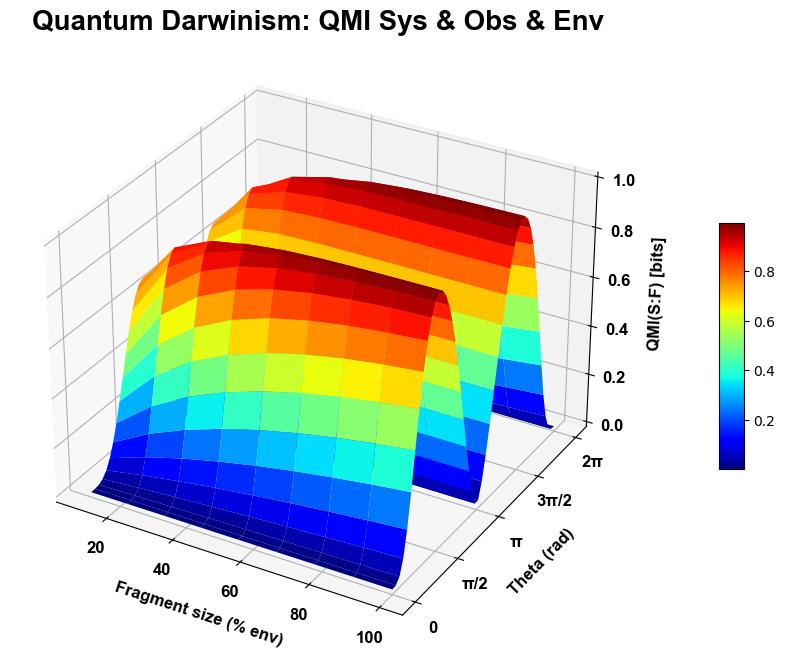

In [ ]:
# PLOT Quantum Darwinism 3D Simulation Sys + Obs + Envir
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
%matplotlib inline
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

# Load dữ liệu từ file pkl
with open("quantum_darwinism_data.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
Theta = loaded_data["Theta"]
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ lại 3D plot
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(FS, Theta, QMI_matrix, cmap='jet')

ax.set_xlabel('Fragment size (% env)', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_ylabel('Theta (rad)', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_zlabel('QMI(S:F) [bits]', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_title('Quantum Darwinism: QMI Sys & Obs & Env', fontsize=20, fontweight='bold', fontname='Arial')


ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'],
                   fontweight='bold', fontname='Arial')


ax.tick_params(axis='x', labelsize=12, width=1.5)
ax.tick_params(axis='y', labelsize=12, width=1.5)
ax.tick_params(axis='z', labelsize=12, width=1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')

fig.colorbar(surf, shrink=0.4, aspect=10, pad = 0.1)
plt.show()



Simulating QMI vs Theta: 100%|██████████| 50/50 [03:21<00:00,  4.02s/it]


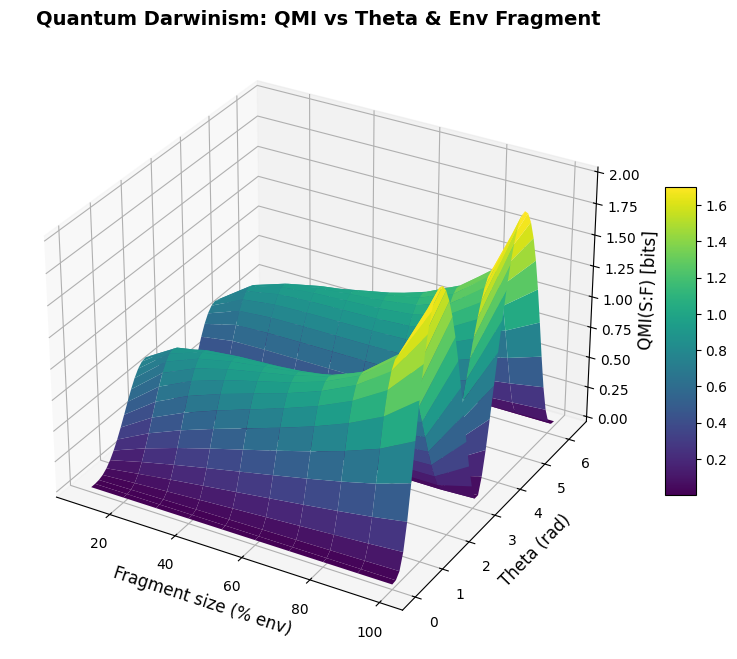

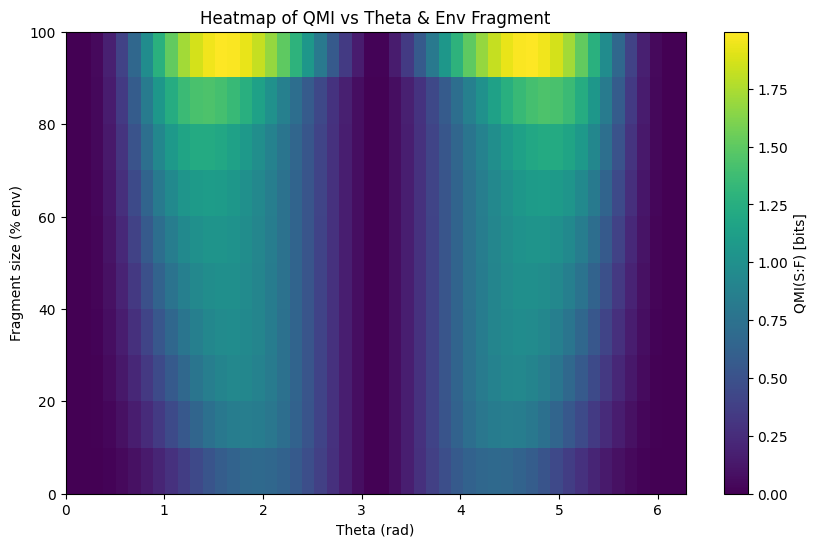

In [ ]:
# Quantum Darwinism 3D Simulation (System + Envir)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import os
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

# ================== Classes ==================
class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Build quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_envir = list(range(1, self.n)) # environment qubits (no observer)

        qc.u(self.theta, self.phi, 0, qb_sys)
        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE

# ================== Helper Function ==================
def compute_qmi(theta, env_qubits, numQubits, QI_calc):
    qc = QCircuit(theta, 0, numQubits)
    rho_S = qc.get_reduced_dm([0])
    qmi_vals = []
    for i in range(len(env_qubits)):
        Ef = env_qubits[:i+1]
        rho_Ef   = qc.get_reduced_dm(Ef)
        rho_SEf  = qc.get_reduced_dm([0]+Ef)
        qmi_vals.append(QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf))
    return qmi_vals

# ================== MAIN SIMULATION ==================
numQubits = 11
phi = 0
env_qubits = list(range(1, numQubits))  # q1..q10 (no observer)
QI_calc = QuantumInformation()

theta_vals = np.linspace(0, 2*np.pi, 50)   # 50 steps
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100  # fragment size %

Theta, FS = np.meshgrid(theta_vals, fs)

# Parallel + Progress bar
results = Parallel(n_jobs=-1)(
    delayed(compute_qmi)(theta, env_qubits, numQubits, QI_calc) 
    for theta in tqdm(theta_vals, desc="Simulating QMI vs Theta")
)

QMI_matrix = np.array(results).T  # convert results into matrix

# ================== 3D Plot ==================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(FS, Theta, QMI_matrix, cmap='viridis')

ax.set_xlabel('Fragment size (% env)', fontsize=12)
ax.set_ylabel('Theta (rad)', fontsize=12)
ax.set_zlabel('QMI(S:F) [bits]', fontsize=12)
ax.set_title('Quantum Darwinism: QMI vs Theta & Env Fragment', fontsize=14, fontweight='bold')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

# ================== Optional Heatmap ==================
plt.figure(figsize=(10,6))
plt.imshow(QMI_matrix, aspect='auto', origin='lower',
           extent=[0, 2*np.pi, 0, 100], cmap='viridis')
plt.colorbar(label='QMI(S:F) [bits]')
plt.xlabel('Theta (rad)')
plt.ylabel('Fragment size (% env)')
plt.title('Heatmap of QMI vs Theta & Env Fragment')
plt.show()

# ================== Save Data ==================
data_to_save = {
    "FS": FS,
    "Theta": Theta,
    "QMI_matrix": QMI_matrix
}

with open("quantum_darwinism_data_no_obs.pkl", "wb") as f:
    pickle.dump(data_to_save, f)


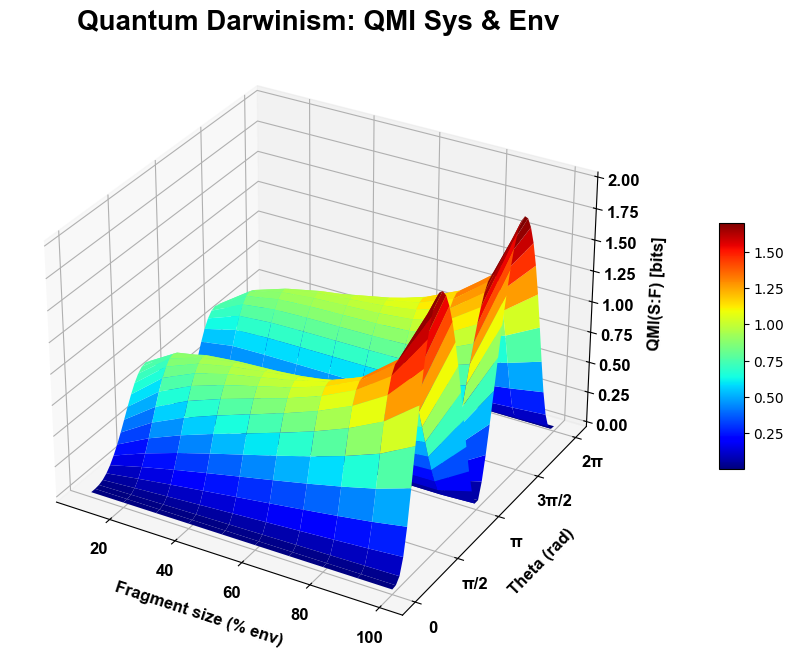

In [ ]:
# PLOT Quantum Darwinism 3D Simulation Sys + Envir
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import numpy as np
%matplotlib inline
os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

# Load dữ liệu từ file pkl
with open("quantum_darwinism_data_no_obs.pkl", "rb") as f:
    loaded_data = pickle.load(f)

FS = loaded_data["FS"]
Theta = loaded_data["Theta"]
QMI_matrix = loaded_data["QMI_matrix"]

# Vẽ lại 3D plot
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(FS, Theta, QMI_matrix, cmap='jet')

ax.set_xlabel('Fragment size (% env)', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_ylabel('Theta (rad)', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_zlabel('QMI(S:F) [bits]', fontsize=12, fontweight='bold', fontname='Arial', labelpad = 8)
ax.set_title('Quantum Darwinism: QMI Sys & Env', fontsize=20, fontweight='bold', fontname='Arial')


ax.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'],
                   fontweight='bold', fontname='Arial')


ax.tick_params(axis='x', labelsize=12, width=1.5)
ax.tick_params(axis='y', labelsize=12, width=1.5)
ax.tick_params(axis='z', labelsize=12, width=1.5)


for label in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    label.set_fontweight('bold')
    label.set_fontname('Arial')

fig.colorbar(surf, shrink=0.4, aspect=10, pad = 0.1)
plt.show()



**QMI and Holevo information with no obsever**

🔬 Quantum Darwinism: System↔Environment ONLY (n=11 qubits)


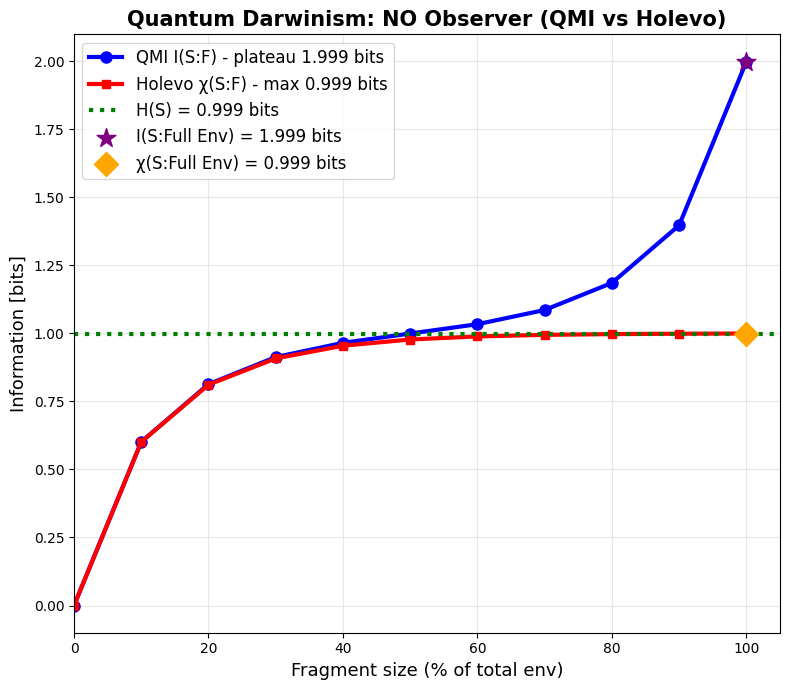

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


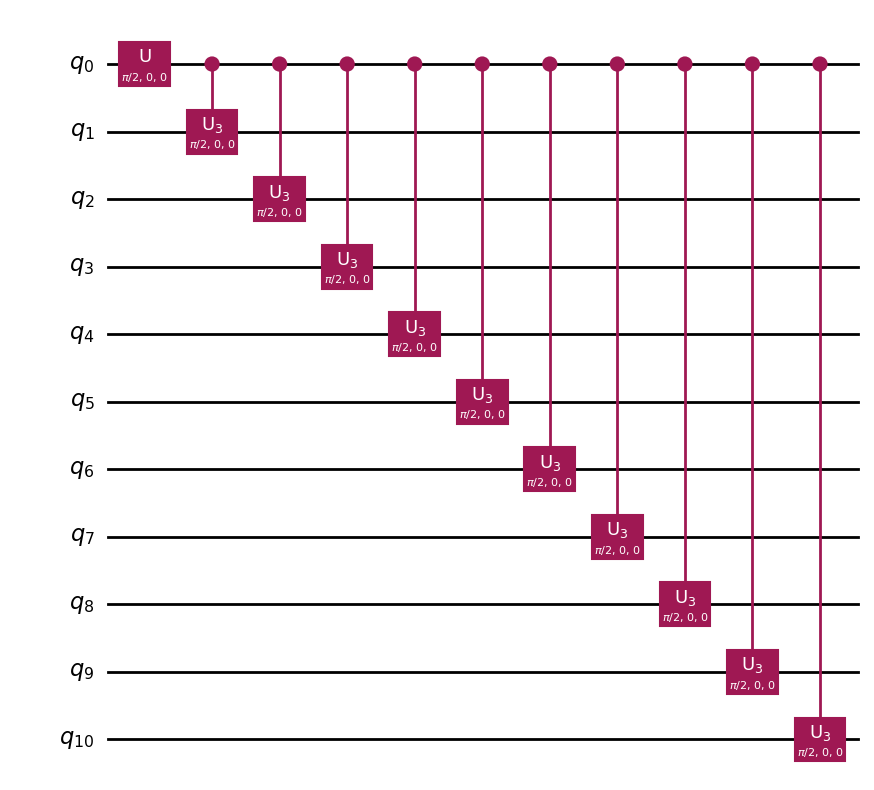

In [ ]:
# Quantum mutual information + Holevo information: system + environment - no observer (pi/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")
%matplotlib inline

class QCircuit:     
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # ✅ Bỏ hẳn observer - chỉ System + Environment
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit (q0)
        qb_envir = list(range(1, self.n)) # environment qubits (q1..q10)
        
        # System prepare |+> state
        qc.u(self.theta, self.phi, 0, qb_sys)
        
        # Environment nối trực tiếp với System
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])  # control=q0, target=env_i
        
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
     
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  

class QuantumInformation(): 
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE

    def HolevoBound(self, state): 
        vne = self.VNE(state)
        eigenvalues, eigenvectors = np.linalg.eigh(state)
        sumX = 0
        for i in range(len(eigenvalues)): 
            vec = eigenvectors[:, i]
            pure_state = np.outer(vec, np.conjugate(vec))
            sumX += eigenvalues[i] * self.VNE(pure_state)
        return vne - sumX
    
# ========== RUN SIMULATION ==========
numQubits = 11  # q0=system, q1..q10=env (bỏ observer)
theta, phi = np.pi/2, 0  # |+> state
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

print(f"🔬 Quantum Darwinism: System↔Environment ONLY (n={numQubits} qubits)")
print("="*60)

# 1. System state
rho_S = qc.get_reduced_dm([0])         

# 2. QMI(S:Environment fragments)
env_qubits = list(range(1, numQubits))  # q1..q10
results_S_Envir = []
results_Holevo = []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  
    rho_Ef   = qc.get_reduced_dm(Ef)     
    rho_SEf  = qc.get_reduced_dm([0]+Ef) 
    
    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_Ef)
    results_Holevo.append(Holevo_Ef)

# 3. Full Environment
rho_E_full  = qc.get_reduced_dm(env_qubits)      
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)
Holevo_E_full = QI_calc.HolevoBound(rho_E_full)

# ========== PLOT: QMI + Holevo ==========
plt.figure(figsize=(8,7))

fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100
fs_ext = np.concatenate([[0], fs])
results_ext = np.concatenate([[0.0], results_S_Envir])
results_Holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'QMI I(S:F) - plateau {max(results_S_Envir):.3f} bits')
plt.plot(fs_ext, results_Holevo_ext, 'r-s', linewidth=3, markersize=6,
         label=f'Holevo χ(S:F) - max {max(results_Holevo):.3f} bits')

plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')
plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)
plt.scatter(100, Holevo_E_full, color='orange', s=150, marker='D',
            label=f'χ(S:Full Env) = {Holevo_E_full:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env)', fontsize=13)
plt.ylabel('Information [bits]', fontsize=13)
plt.title('Quantum Darwinism: NO Observer (QMI vs Holevo)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

# ========== CIRCUIT DIAGRAM ==========
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()


**QMI and Holevo information with obsever**

Quantum Darwinism Simulation (n=11 qubits)


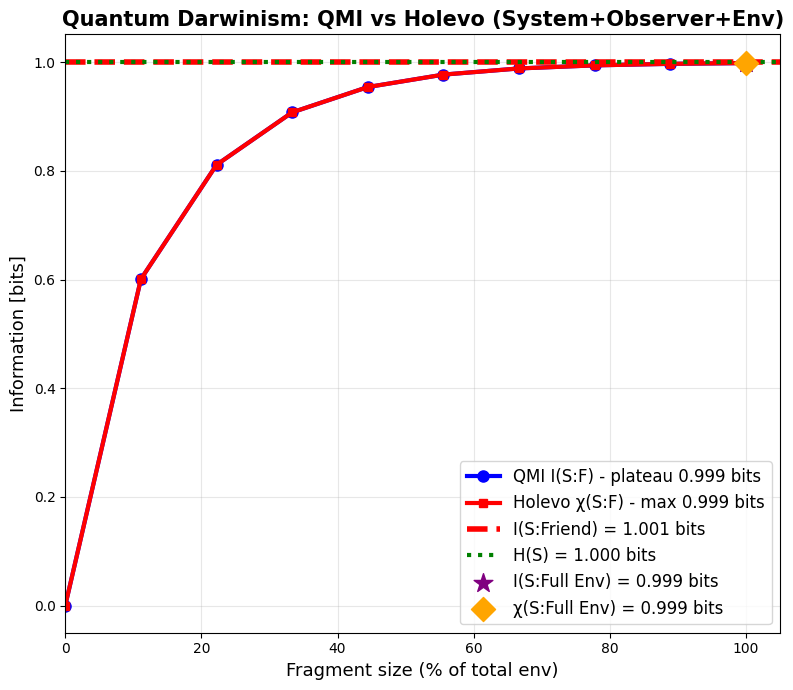


RESULTS:
H(S)              = 1.000 bits
I(S:Friend)       = 1.001 bits
I(S:Full Env)     = 0.999 bits
χ(S:Full Env)     = 0.999 bits
Max fragment I    = 0.999 bits
Max fragment χ    = 0.999 bits


In [3]:
# Quantum Darwinism Simulation: System + Observer + Environment (pi/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

# ===================== Quantum Circuit =====================
class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit
        qb_envir = list(range(2, self.n)) # environment qubits
        
        # System prepare |+>
        qc.u(self.theta, self.phi, 0, qb_sys)
        # Observer entangled with system
        qc.cx(qb_sys, qb_obser)
        # Environment coupled to system
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  

# ===================== Quantum Information =====================
class QuantumInformation(): 
    def VNE(self, state): 
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    
    def holevo_bound(self, rho_E): # Holevo χ(S:F) = S(ρ_E) - Σ p_i S(ρ_E^i) /// xem lại theo công thức só 14.
        vne = self.VNE(rho_E)
        eigenvalues, eigenvectors = np.linalg.eigh(rho_E)
        sumX = 0
        for i in range(len(eigenvalues)):
            vec = eigenvectors[:, i]
            pure_state = np.outer(vec, np.conjugate(vec))
            sumX += eigenvalues[i] * self.VNE(pure_state)
        return vne - sumX

# ===================== MAIN SIMULATION =====================
numQubits = 11
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*60)

# --- System & Observer ---
rho_S    = qc.get_reduced_dm([0])         
rho_Obs  = qc.get_reduced_dm([1])         
rho_SObs = qc.get_reduced_dm([0,1])       
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# --- Environment fragments ---
env_qubits = list(range(2, numQubits))  
results_S_Envir = []
results_Holevo = []
for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    
    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Holevo
    Holevo_Ef = QI_calc.holevo_bound(rho_Ef)
    results_Holevo.append(Holevo_Ef)

# --- Full Environment ---
rho_E_full  = qc.get_reduced_dm(env_qubits)      
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)
Holevo_E_full = QI_calc.holevo_bound(rho_E_full)

# ===================== PLOT =====================
plt.figure(figsize=(8,7))

fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100
fs_ext = np.concatenate([[0], fs])
results_ext = np.concatenate([[0.0], results_S_Envir])
results_Holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'QMI I(S:F) - plateau {max(results_S_Envir):.3f} bits')
plt.plot(fs_ext, results_Holevo_ext, 'r-s', linewidth=3, markersize=6,
         label=f'Holevo χ(S:F) - max {max(results_Holevo):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)
plt.scatter(100, Holevo_E_full, color='orange', s=150, marker='D',
            label=f'χ(S:Full Env) = {Holevo_E_full:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env)', fontsize=13)
plt.ylabel('Information [bits]', fontsize=13)
plt.title('Quantum Darwinism: QMI vs Holevo (System+Observer+Env)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

# --- Results ---
H_S = QI_calc.VNE(rho_S)
print("\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits")
print(f"χ(S:Full Env)     = {Holevo_E_full:.3f} bits")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
print(f"Max fragment χ    = {max(results_Holevo):.3f} bits")

# --- Circuit diagram ---
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

# --- Save data ---
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'results_Holevo_ext': results_Holevo_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'Holevo_E_full': Holevo_E_full,
    'results_S_Envir': results_S_Envir,
    'results_Holevo': results_Holevo,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}
with open('quantum_darwinism_sys_obs_env_pi2_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)


Quantum Darwinism Simulation (n=11 qubits)


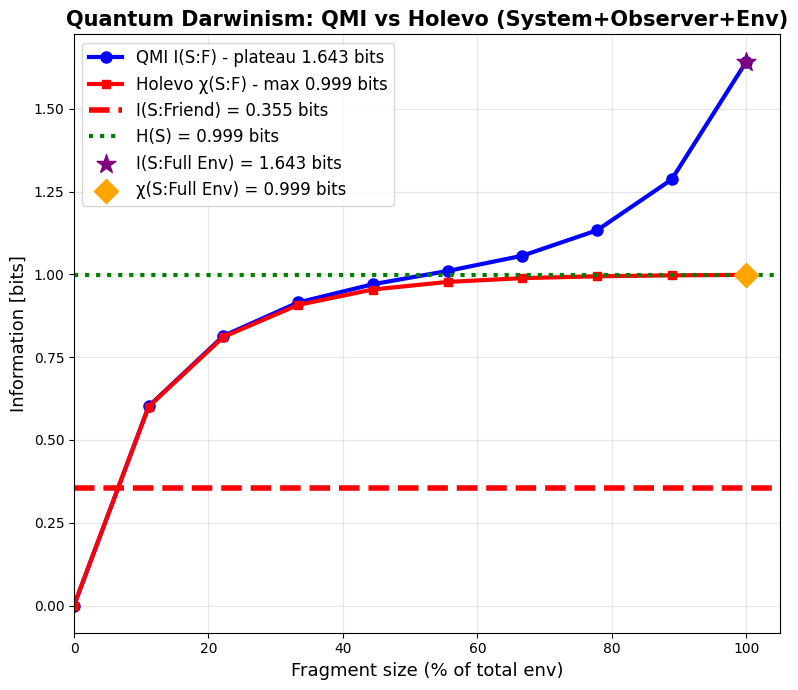


RESULTS:
H(S)              = 0.999 bits
I(S:Friend)       = 0.355 bits
I(S:Full Env)     = 1.643 bits
χ(S:Full Env)     = 0.999 bits
Max fragment I    = 1.643 bits
Max fragment χ    = 0.999 bits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


"\n# --- Save data ---\ndata_to_save = {\n    'fs_ext': fs_ext,\n    'results_ext': results_ext,\n    'results_Holevo_ext': results_Holevo_ext,\n    'QMI_S_Obs': QMI_S_Obs,\n    'H_S': H_S,\n    'QMI_S_Efull': QMI_S_Efull,\n    'Holevo_E_full': Holevo_E_full,\n    'results_S_Envir': results_S_Envir,\n    'results_Holevo': results_Holevo,\n    'numQubits': numQubits,\n    'theta': theta,\n    'phi': phi\n}\nwith open('quantum_darwinism_sys_obs_env_pi2_data.pkl', 'wb') as f:\n    pickle.dump(data_to_save, f) "

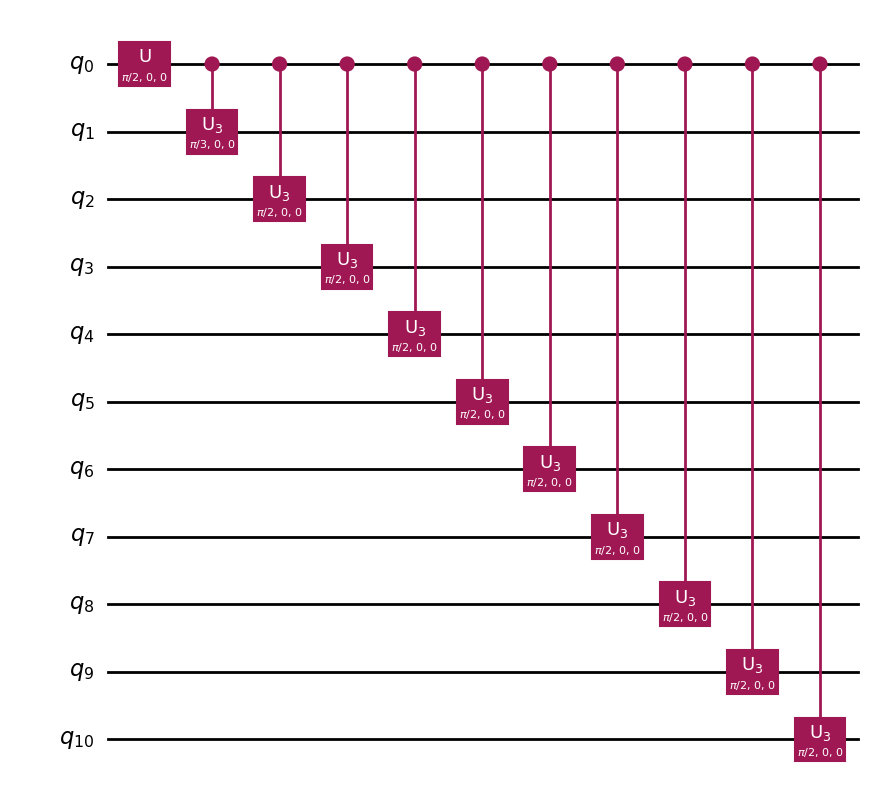

In [5]:
# Quantum Darwinism Simulation: System + Observer + Environment (pi/2) | obsever interaction π/3
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

# ===================== Quantum Circuit =====================
class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Built the quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit (Friend)
        qb_envir = list(range(2, self.n)) # environment qubits
        
        qc.u(self.theta, self.phi, 0, qb_sys)
        # Controlled-U(pi/3) từ q0 (system) sang q1 (observer)
        u_gate = U3Gate(np.pi/3, 0, 0).control(1)
        qc.append(u_gate, [qb_sys, qb_obser])

        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  

# ===================== Quantum Information =====================
class QuantumInformation(): 
    def VNE(self, state): 
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    
    def holevo_bound(self, rho_E): # Holevo χ(S:F) = S(ρ_E) - Σ p_i S(ρ_E^i) /// xem lại theo công thức só 14.
        vne = self.VNE(rho_E)
        eigenvalues, eigenvectors = np.linalg.eigh(rho_E)
        sumX = 0
        for i in range(len(eigenvalues)):
            vec = eigenvectors[:, i]
            pure_state = np.outer(vec, np.conjugate(vec))
            sumX += eigenvalues[i] * self.VNE(pure_state)
        return vne - sumX

# ===================== MAIN SIMULATION =====================
numQubits = 11
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*60)

# --- System & Observer ---
rho_S    = qc.get_reduced_dm([0])         
rho_Obs  = qc.get_reduced_dm([1])         
rho_SObs = qc.get_reduced_dm([0,1])       
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# --- Environment fragments ---
env_qubits = list(range(2, numQubits))  
results_S_Envir = []
results_Holevo = []
for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    
    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Holevo
    Holevo_Ef = QI_calc.holevo_bound(rho_Ef)
    results_Holevo.append(Holevo_Ef)

# --- Full Environment ---
rho_E_full  = qc.get_reduced_dm(env_qubits)      
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)
Holevo_E_full = QI_calc.holevo_bound(rho_E_full)

# ===================== PLOT =====================
plt.figure(figsize=(8,7))

fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100
fs_ext = np.concatenate([[0], fs])
results_ext = np.concatenate([[0.0], results_S_Envir])
results_Holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'QMI I(S:F) - plateau {max(results_S_Envir):.3f} bits')
plt.plot(fs_ext, results_Holevo_ext, 'r-s', linewidth=3, markersize=6,
         label=f'Holevo χ(S:F) - max {max(results_Holevo):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)
plt.scatter(100, Holevo_E_full, color='orange', s=150, marker='D',
            label=f'χ(S:Full Env) = {Holevo_E_full:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env)', fontsize=13)
plt.ylabel('Information [bits]', fontsize=13)
plt.title('Quantum Darwinism: QMI vs Holevo (System+Observer+Env)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

# --- Results ---
H_S = QI_calc.VNE(rho_S)
print("\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits")
print(f"χ(S:Full Env)     = {Holevo_E_full:.3f} bits")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
print(f"Max fragment χ    = {max(results_Holevo):.3f} bits")

# --- Circuit diagram ---
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)


'''
# --- Save data ---
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'results_Holevo_ext': results_Holevo_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'Holevo_E_full': Holevo_E_full,
    'results_S_Envir': results_S_Envir,
    'results_Holevo': results_Holevo,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}
with open('quantum_darwinism_sys_obs_env_pi2_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f) '''


🔬 Quantum Darwinism: System↔Environment ONLY (n=11 qubits)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


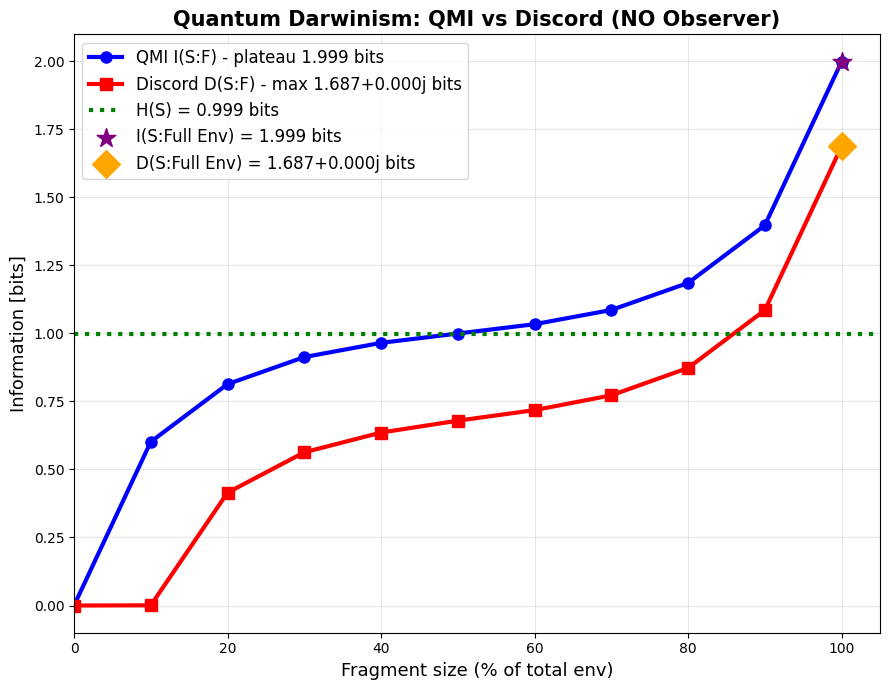

✅ Plot: QMI + Discord curve hoàn thành!


In [3]:
# Quantum Darwinism: System + Environment (NO Observer, pi/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle

class QCircuit:     
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_envir = list(range(1, self.n)) # environment qubits
        
        # System prepare |+> state
        qc.u(self.theta, self.phi, 0, qb_sys)
        
        # Environment entangled directly with system
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])  
        
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
     
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data
         

class QuantumInformation(): 
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    
    def quantum_discord(self, rho_SE, rho_S):
        # Mutual information
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        # Classical correlation J(A:B)
        eigvals, eigvecs = np.linalg.eigh(rho_S)
        cond_entropy = 0
        d_E = rho_SE.shape[0] // rho_S.shape[0]  # dimension of environment
        
        for i in range(len(eigvals)):
            proj_S = np.outer(eigvecs[:, i], np.conj(eigvecs[:, i]))  # 2x2
            proj_SE = np.kron(proj_S, np.eye(d_E))                     # lift to SE space
            p_i = np.trace(proj_SE @ rho_SE)
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr



# ========== RUN SIMULATION ==========
numQubits = 11  # q0=system, q1..q10=env
theta, phi = np.pi/2, 0  # |+> state
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

print(f"🔬 Quantum Darwinism: System↔Environment ONLY (n={numQubits} qubits)")
print("="*60)

# 1. System state
rho_S = qc.get_reduced_dm([0])         

# 2. QMI + Discord vs Environment fragments
env_qubits = list(range(1, numQubits))  
results_S_Envir = []
results_Discord = []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  
    rho_Ef   = qc.get_reduced_dm(Ef)     
    rho_SEf  = qc.get_reduced_dm([0]+Ef) 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_S_Envir.append(QMI_S_Ef)
    results_Discord.append(Discord_S_Ef)

# 3. Full Environment
rho_E_full  = qc.get_reduced_dm(env_qubits)      
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)
Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ========== PLOT ==========
plt.figure(figsize=(9,7))

fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100
fs_ext = np.concatenate([[0], fs])                 
results_ext = np.concatenate([[0.0], results_S_Envir])  
discord_ext = np.concatenate([[0.0], results_Discord])  

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'QMI I(S:F) - plateau {max(results_S_Envir):.3f} bits')
plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=f'Discord D(S:F) - max {max(results_Discord):.3f} bits')

plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')
plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)
plt.scatter(100, Discord_SE_full, color='orange', s=200, marker='D',
            label=f'D(S:Full Env) = {Discord_SE_full:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env)', fontsize=13)
plt.ylabel('Information [bits]', fontsize=13)
plt.title('Quantum Darwinism: QMI vs Discord (NO Observer)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

print("✅ Plot: QMI + Discord curve hoàn thành!")

# ========== CIRCUIT DIAGRAM ==========
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()


In [ ]:
# Quantum mutual information: system + observer + environment pi/2 

from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import pandas as pd

os.chdir("/Users/trandon/Documents/Theoretical Physics Articles")

%matplotlib inline

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): # Built the quantum circuit
        qc = QuantumCircuit(self.n)
        qb_sys   = 0 # system qubit
        qb_obser = 1 # observer qubit (Friend)
        qb_envir = list(range(2, self.n)) # environment qubits
        
        qc.u(self.theta, self.phi, 0, qb_sys)
        qc.cx(qb_sys, qb_obser)
        
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        """keep_qubits = qubits MUỐN GIỮ LẠI, tự động tính trace_out"""
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data  # NumPy array cho VNE

class QuantumInformation(): 
    def VNE(self, state): # von Neumann entropy
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]  # Numerical stability
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    
    def holevo_info(self, rho_S, rho_SE):
        H_S = self.VNE(rho_S)
        H_SE = self.VNE(rho_SE)
        H_E = self.VNE(partial_trace(DensityMatrix(rho_SE.data), [0]))  # trace out S
        return H_S - (H_SE - H_E)
    def quantum_discord(self, rho_SE, rho_S):
        # Mutual information
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        # Classical correlation J(A:B)
        eigvals, eigvecs = np.linalg.eigh(rho_S)
        cond_entropy = 0
        d_E = rho_SE.shape[0] // rho_S.shape[0]  # dimension of environment
        
        for i in range(len(eigvals)):
            proj_S = np.outer(eigvecs[:, i], np.conj(eigvecs[:, i]))  # 2x2
            proj_SE = np.kron(proj_S, np.eye(d_E))                     # lift to SE space
            p_i = np.trace(proj_SE @ rho_SE)
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr
    
# ========== MAIN SIMULATION ==========
numQubits = 11
theta, phi = np.pi/2, 0  # |+> 
qc = QCircuit(theta, phi, numQubits)
rho_total = qc.DensityMatrix()
QI_calc = QuantumInformation()

print(f"Quantum Darwinism Simulation (n={numQubits} qubits)")
print("="*50)

# ========== 1. QMI(S : Observer/Friend) ==========
rho_S    = qc.get_reduced_dm([0])         # System q0 
rho_Obs  = qc.get_reduced_dm([1])         # Observer q1 
rho_SObs = qc.get_reduced_dm([0,1])       # S+Observer 
QMI_S_Obs = QI_calc.quantum_mutual_I(rho_S, rho_Obs, rho_SObs)

# ========== 2. QMI(S : Environment fragments) ==========
env_qubits = list(range(2, numQubits))  # q2..q10
results_S_Envir = []
redundancy_points = []


for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]                  # Fragment [q2], [q2,q3], ...
    rho_Ef   = qc.get_reduced_dm(Ef)     # Fragment state 
    rho_SEf  = qc.get_reduced_dm([0]+Ef) # System + fragment 
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    
    # Redundancy test
    H_S = QI_calc.VNE(rho_S)
    is_redundant = QMI_S_Ef >= 0.9 * H_S
    redundancy_points.append(is_redundant)

# ========== 3. FULL Environment (để thấy 2H(S)) ==========
rho_E_full  = qc.get_reduced_dm(env_qubits)      # Toàn bộ env q2..q10
rho_SE_full = qc.get_reduced_dm([0]+env_qubits)  # S + full env
QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

# ========== QMI plot ==========
plt.figure(figsize=(8,7))


fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits) * 100

fs_ext = np.concatenate([[0], fs])                
results_ext = np.concatenate([[0.0], results_S_Envir])  # I(0)=0

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=f'I(S:Env_fragment) - plateau {max(results_S_Envir):.3f} bits')

plt.axhline(QMI_S_Obs, color='r', linewidth=4, linestyle='--',
            label=f'I(S:Friend) = {QMI_S_Obs:.3f} bits')
plt.axhline(QI_calc.VNE(rho_S), color='g', linewidth=3, linestyle=':',
            label=f'H(S) = {QI_calc.VNE(rho_S):.3f} bits')

plt.scatter(100, QMI_S_Efull, color='purple', s=200, marker='*',
            label=f'I(S:Full Env) = {QMI_S_Efull:.3f} bits', zorder=5)

plt.xlabel('Fragment size (% of total env qubits)', fontsize=13)
plt.ylabel('Quantum Mutual Information I(S:F) [bits]', fontsize=13)
plt.title('Quantum Darwinism: Redundancy Plateau', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.xlim(0, 105)
plt.ylim(0, max(QMI_S_Efull*1.1, 2.1))
plt.tight_layout()
plt.show()
plt.clf() 
# ========== RESULTS ==========
H_S = QI_calc.VNE(rho_S)
print(f"\nRESULTS:")
print(f"H(S)              = {H_S:.3f} bits")
print(f"I(S:Friend)       = {QMI_S_Obs:.3f} bits ({QMI_S_Obs/H_S*100:.1f}% of H(S))")
print(f"I(S:Full Env)     = {QMI_S_Efull:.3f} bits ({QMI_S_Efull/H_S*100:.1f}% of 2H(S))")
print(f"Max fragment I    = {max(results_S_Envir):.3f} bits")
#print(f"Redundancy starts = fragment #{next(i+1 for i,r in enumerate(redundancy_points) if r)}/9")

# === Quantum Circuit plot ===
fig = qc.Circuit().draw(output='mpl', style='iqx')
fig.set_size_inches(14,10)
plt.show()

#=== Save Data ===
data_to_save = {
    'fs_ext': fs_ext,
    'results_ext': results_ext,
    'QMI_S_Obs': QMI_S_Obs,
    'H_S': H_S,
    'QMI_S_Efull': QMI_S_Efull,
    'results_S_Envir': results_S_Envir,
    'numQubits': numQubits,
    'theta': theta,
    'phi': phi
}

with open('quantum_darwinism_sys_envir_obs_pi2_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)




**Quantum Darwinism: QMI + Holevo + Discord + I_acc**

In [2]:
# Quantum Darwinism: System + Environment fragments (pi/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        
        # System prepare |+>
        qc.h(qb_sys)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 
    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E), proj_S) 
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr
    
# ========== MAIN ==========
numQubits = 11  # q0 system, q1..q10 environment
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()

rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(1, numQubits))

results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):

    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)

    # QMI
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Quantum Discord
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)


rho_E_full  = qc.get_reduced_dm(env_qubits)

rho_SE_full = qc.get_reduced_dm([0]+env_qubits)

QMI_S_Efull = QI_calc.quantum_mutual_I(rho_S, rho_E_full, rho_SE_full)

Holevo_E_full = QI_calc.HolevoBound(rho_SE_full, rho_S)

Discord_SE_full = QI_calc.quantum_discord(rho_SE_full, rho_S)

# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,
    "QMI_S_Efull": QMI_S_Efull,
    "Holevo_E_full": Holevo_E_full,
    "Discord_SE_full": Discord_SE_full
}

with open("quantum_darwinism_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_QMI_Holevo_Discord.pkl")



/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_77383/1946319954.py:66: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_77383/1946319954.py:66: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_77383/1946319954.py:66: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_77383/1946319954.py:69: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_77383/1946319954.py:69: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_77383/1946319954.py:69: RuntimeW

Saved quantum_darwinism_QMI_Holevo_Discord.pkl


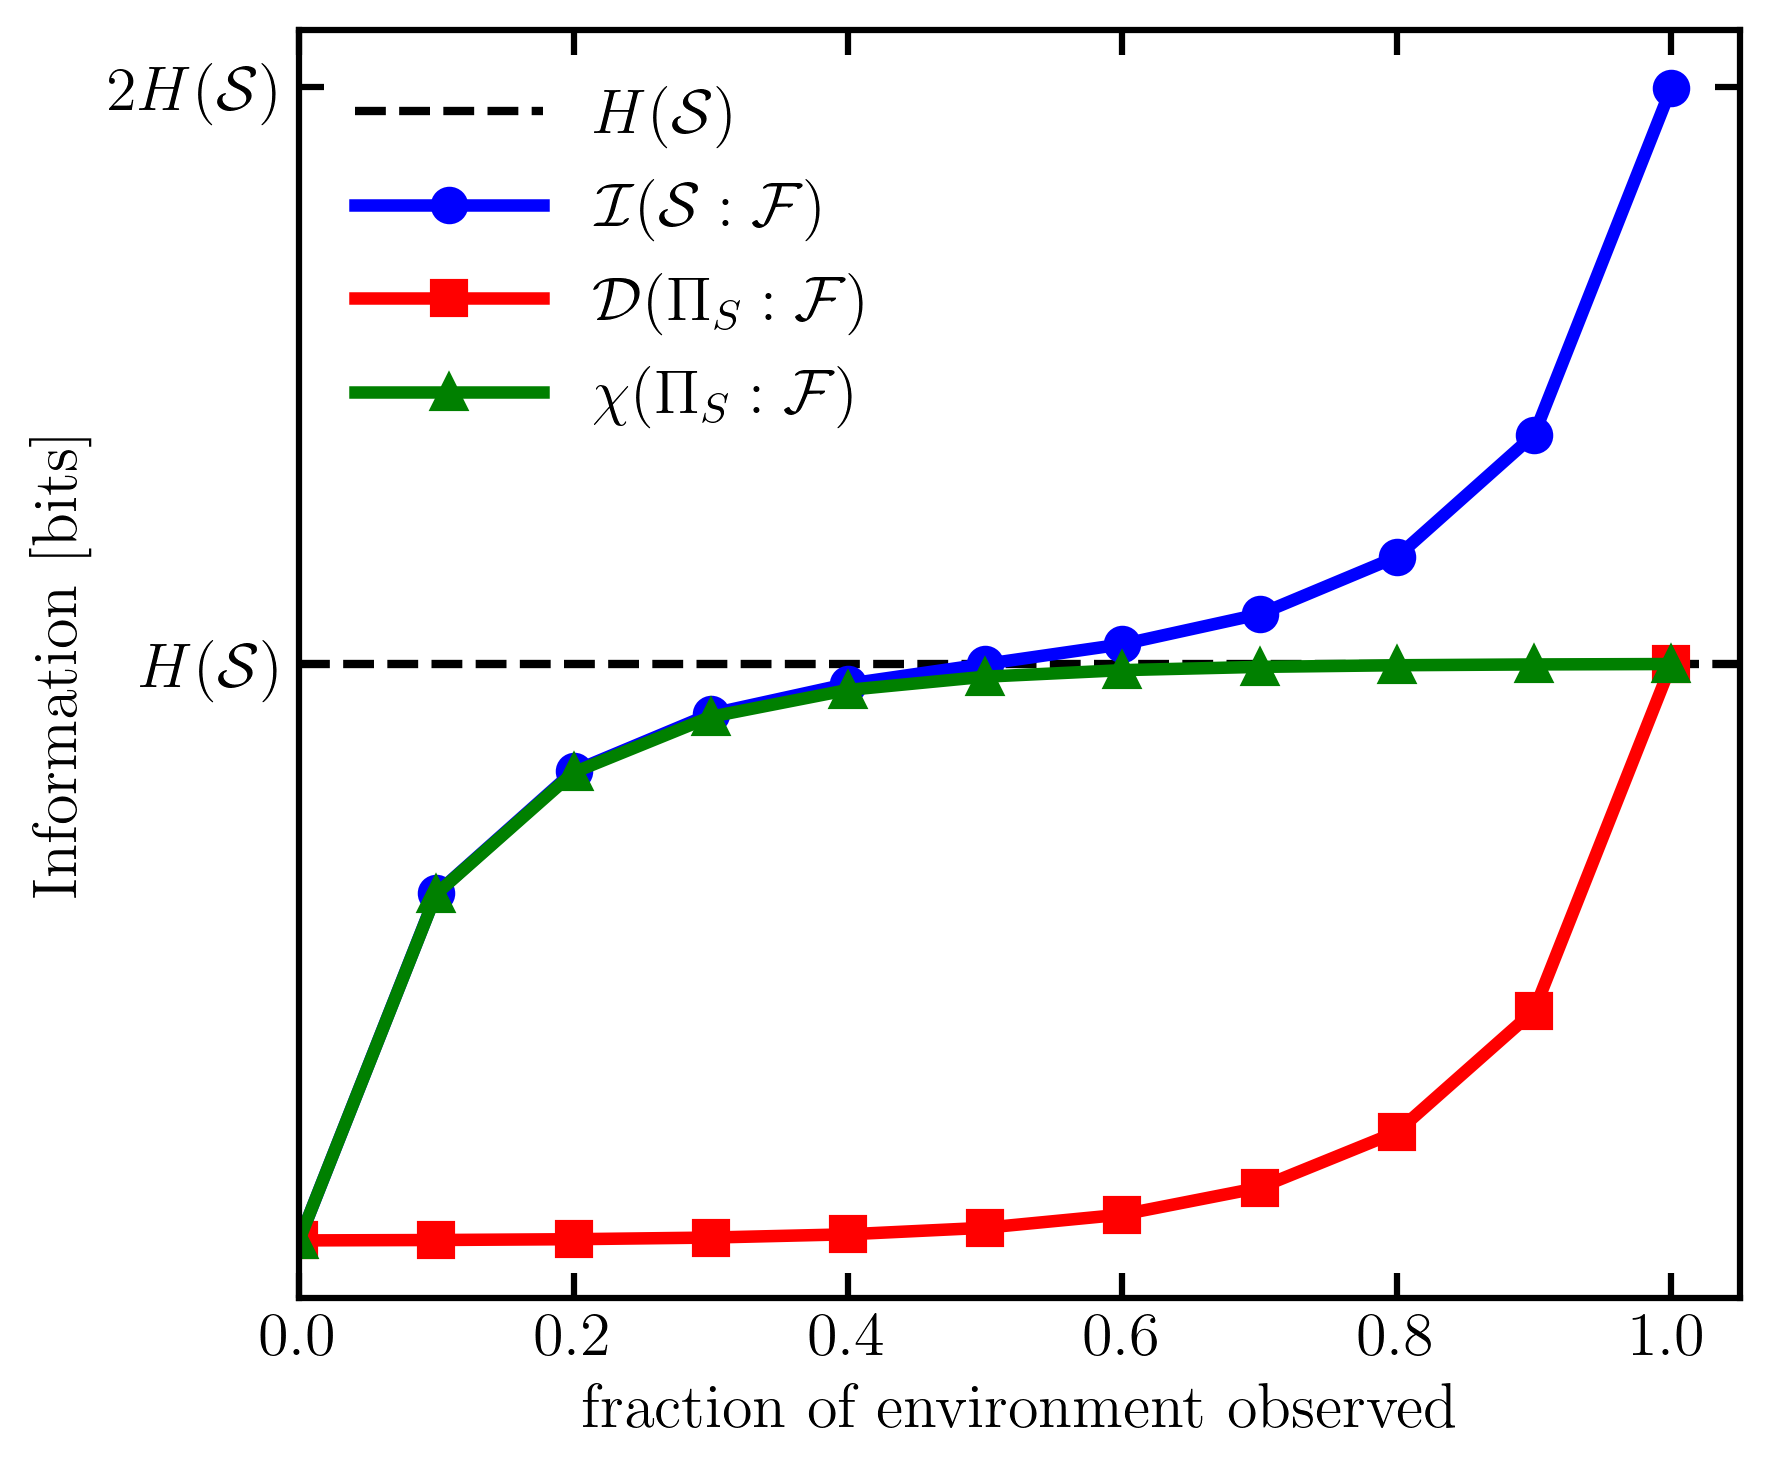

In [1]:
# ========== PLOT ==========

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False
# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(6,5))
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

plt.axhline(1.0, color='black', linestyle='--', linewidth=2,
            label=r"$H(\mathcal{S})$")

plt.plot(fs_ext, results_ext, 'b-o', linewidth=3, markersize=8,
         label=r"$\mathcal{I}(\mathcal{S}:\mathcal{F})$")

plt.plot(fs_ext, discord_ext, 'r-s', linewidth=3, markersize=8,
         label=r"$\mathcal{D}(\Pi_{S}:\mathcal{F})$")

plt.plot(fs_ext, holevo_ext, 'g-^', linewidth=3, markersize=8,
         label=r"$\chi(\Pi_S:\mathcal{F})$")


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize = 15)
plt.xticks(fontsize=15)
plt.xlabel('fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')
plt.legend(fontsize=15, frameon=False, loc='best', handlelength=3)
plt.grid(False)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()



In [8]:
# Quantum Darwinism: System + Observer + Environment (pi/2)
from qiskit import QuantumCircuit
from qiskit import quantum_info as qi
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.circuit.library import U3Gate
import numpy as np
import matplotlib.pyplot as plt

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_obser = 1
        qb_envir = list(range(2, self.n))
        
        # System prepare |+>
        qc.u(self.theta, self.phi, 0, qb_sys)
        # System entangled with observer
        qc.cx(qb_sys, qb_obser)
        # System entangled with environment
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 
    
    def DensityMatrix(self): 
        return qi.DensityMatrix.from_instruction(self.Circuit())  
    
    def get_reduced_dm(self, keep_qubits):
        trace_out_qubits = [i for i in range(self.n) if i not in keep_qubits]
        rho = self.DensityMatrix()
        return partial_trace(rho, trace_out_qubits).data

class QuantumInformation(): 
    # Von Neumann entropy
    def VNE(self, state):
        eigenvalues, _ = np.linalg.eigh(state)
        eigenvalues = eigenvalues[eigenvalues > 1e-12]
        return -np.sum(eigenvalues * np.log2(eigenvalues))
    # Quantum mutual information I(S:E) = H(S) + H(E) - H(SE)
    def quantum_mutual_I(self, S_State, E_State, SE_State):
        VNE_S  = self.VNE(S_State)
        VNE_E  = self.VNE(E_State)
        VNE_SE = self.VNE(SE_State)
        return VNE_S + VNE_E - VNE_SE
    def HolevoBound(self, rho_SEf, rho_S):
            
            rho_Ef = partial_trace(DensityMatrix(rho_SEf), [0]).data
            S_Ef = self.VNE(rho_Ef)
            
            sum_cond_entropy = 0
            d_Ef = rho_SEf.shape[0] // 2  # Chỉ cần dòng này là đủ, vừa sạch code vừa chạy nhanh
            
            # pointer basis of system S
            proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
            proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
            computational_projections = [proj_0, proj_1]
            
            for proj_S in computational_projections:
                proj_SEf = np.kron(np.eye(d_Ef), proj_S)
                # probability of outcome i of POVM \Pi_S on System
                p_i = np.real(np.trace(proj_SEf @ rho_SEf))
                
                if p_i > 1e-12:
                    rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
                    rho_Ef_i = partial_trace(DensityMatrix(rho_SEf_i), [0]).data
                    sum_cond_entropy += p_i * self.VNE(rho_Ef_i)
                    
            return S_Ef - sum_cond_entropy
    # Quantum Discord D(S:F) = I(S:F) - χ(S:F) sử dụng Pointer Basis đồng bộ
    def quantum_discord(self, rho_SE, rho_S):
        rho_E = partial_trace(DensityMatrix(rho_SE), [0]).data
        I_AB = self.quantum_mutual_I(rho_S, rho_E, rho_SE)
        
        cond_entropy = 0
        d_E = rho_SE.shape[0] // 2  # Đồng bộ hệ S kích thước 2
        
        # Pointer basis giống y hệt HolevoBound
        proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
        proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
        pointer_projections = [proj_0, proj_1]
        
        for proj_S in pointer_projections:
            # Sửa lại thứ tự kron để khớp với quy ước Qiskit Little-Endian
            proj_SE = np.kron(np.eye(d_E), proj_S) 
            
            p_i = np.real(np.trace(proj_SE @ rho_SE))
            if p_i > 1e-12:
                rho_SE_i = (proj_SE @ rho_SE @ proj_SE) / p_i
                rho_B_i = partial_trace(DensityMatrix(rho_SE_i), [0]).data
                cond_entropy += p_i * self.VNE(rho_B_i)
        
        S_B = self.VNE(rho_E)
        classical_corr = S_B - cond_entropy
        return I_AB - classical_corr

# ========== MAIN ==========
numQubits = 12  # q0 system, q1 observer, q2..q11 environment
theta, phi = np.pi/3, 0
qc = QCircuit(theta, phi, numQubits)
QI_calc = QuantumInformation()
rho_S = qc.get_reduced_dm([0])
env_qubits = list(range(2, numQubits))

# Between system S and environment E
results_S_Envir, results_Discord, results_Holevo = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_SEf  = qc.get_reduced_dm([0]+Ef)
    # QMI ( S: E_f )
    QMI_S_Ef = QI_calc.quantum_mutual_I(rho_S, rho_Ef, rho_SEf)
    results_S_Envir.append(QMI_S_Ef)
    # Holevo ( S: E_f )
    Holevo_Ef = QI_calc.HolevoBound(rho_SEf, rho_S)
    results_Holevo.append(Holevo_Ef)
    # Discord ( S: E_f )
    Discord_S_Ef = QI_calc.quantum_discord(rho_SEf, rho_S)
    results_Discord.append(Discord_S_Ef)
 

# Betwween obsever F and environment E
results_F_Envir, results_Discord_F, results_Holevo_F = [], [], []

for k in range(1, len(env_qubits)+1):
    Ef = env_qubits[:k]
    rho_Ef   = qc.get_reduced_dm(Ef)
    rho_FEf  = qc.get_reduced_dm([1]+Ef)
    # QMI ( F: E_f )
    QMI_F_Ef = QI_calc.quantum_mutual_I(qc.get_reduced_dm([1]), rho_Ef, rho_FEf)
    results_F_Envir.append(QMI_F_Ef)
    # Holevo ( F: E_f )
    Holevo_F_Ef = QI_calc.HolevoBound(rho_FEf, qc.get_reduced_dm([1]))
    results_Holevo_F.append(Holevo_F_Ef)
    # Discord ( F: E_f )
    Discord_F_Ef = QI_calc.quantum_discord(rho_FEf, qc.get_reduced_dm([1]))
    results_Discord_F.append(Discord_F_Ef)
# ===================== SAVING ====================

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

data = {
    "results_S_Envir": results_S_Envir,
    "results_Holevo": results_Holevo,
    "results_Discord": results_Discord,

    "results_F_Envir": results_F_Envir,
    "results_Holevo_F": results_Holevo_F,
    "results_Discord_F": results_Discord_F,
}

with open("quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl", "wb") as f:
    pickle.dump(data, f)

print("Saved quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl")


/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_86393/3960926187.py:67: RuntimeWarning: divide by zero encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_86393/3960926187.py:67: RuntimeWarning: overflow encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_86393/3960926187.py:67: RuntimeWarning: invalid value encountered in matmul
  p_i = np.real(np.trace(proj_SEf @ rho_SEf))
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_86393/3960926187.py:70: RuntimeWarning: divide by zero encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_86393/3960926187.py:70: RuntimeWarning: overflow encountered in matmul
  rho_SEf_i = (proj_SEf @ rho_SEf @ proj_SEf) / p_i
/var/folders/g9/m8256c0d60q4_z27hsb5nhtw0000gn/T/ipykernel_86393/3960926187.py:70: RuntimeW

Saved quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl


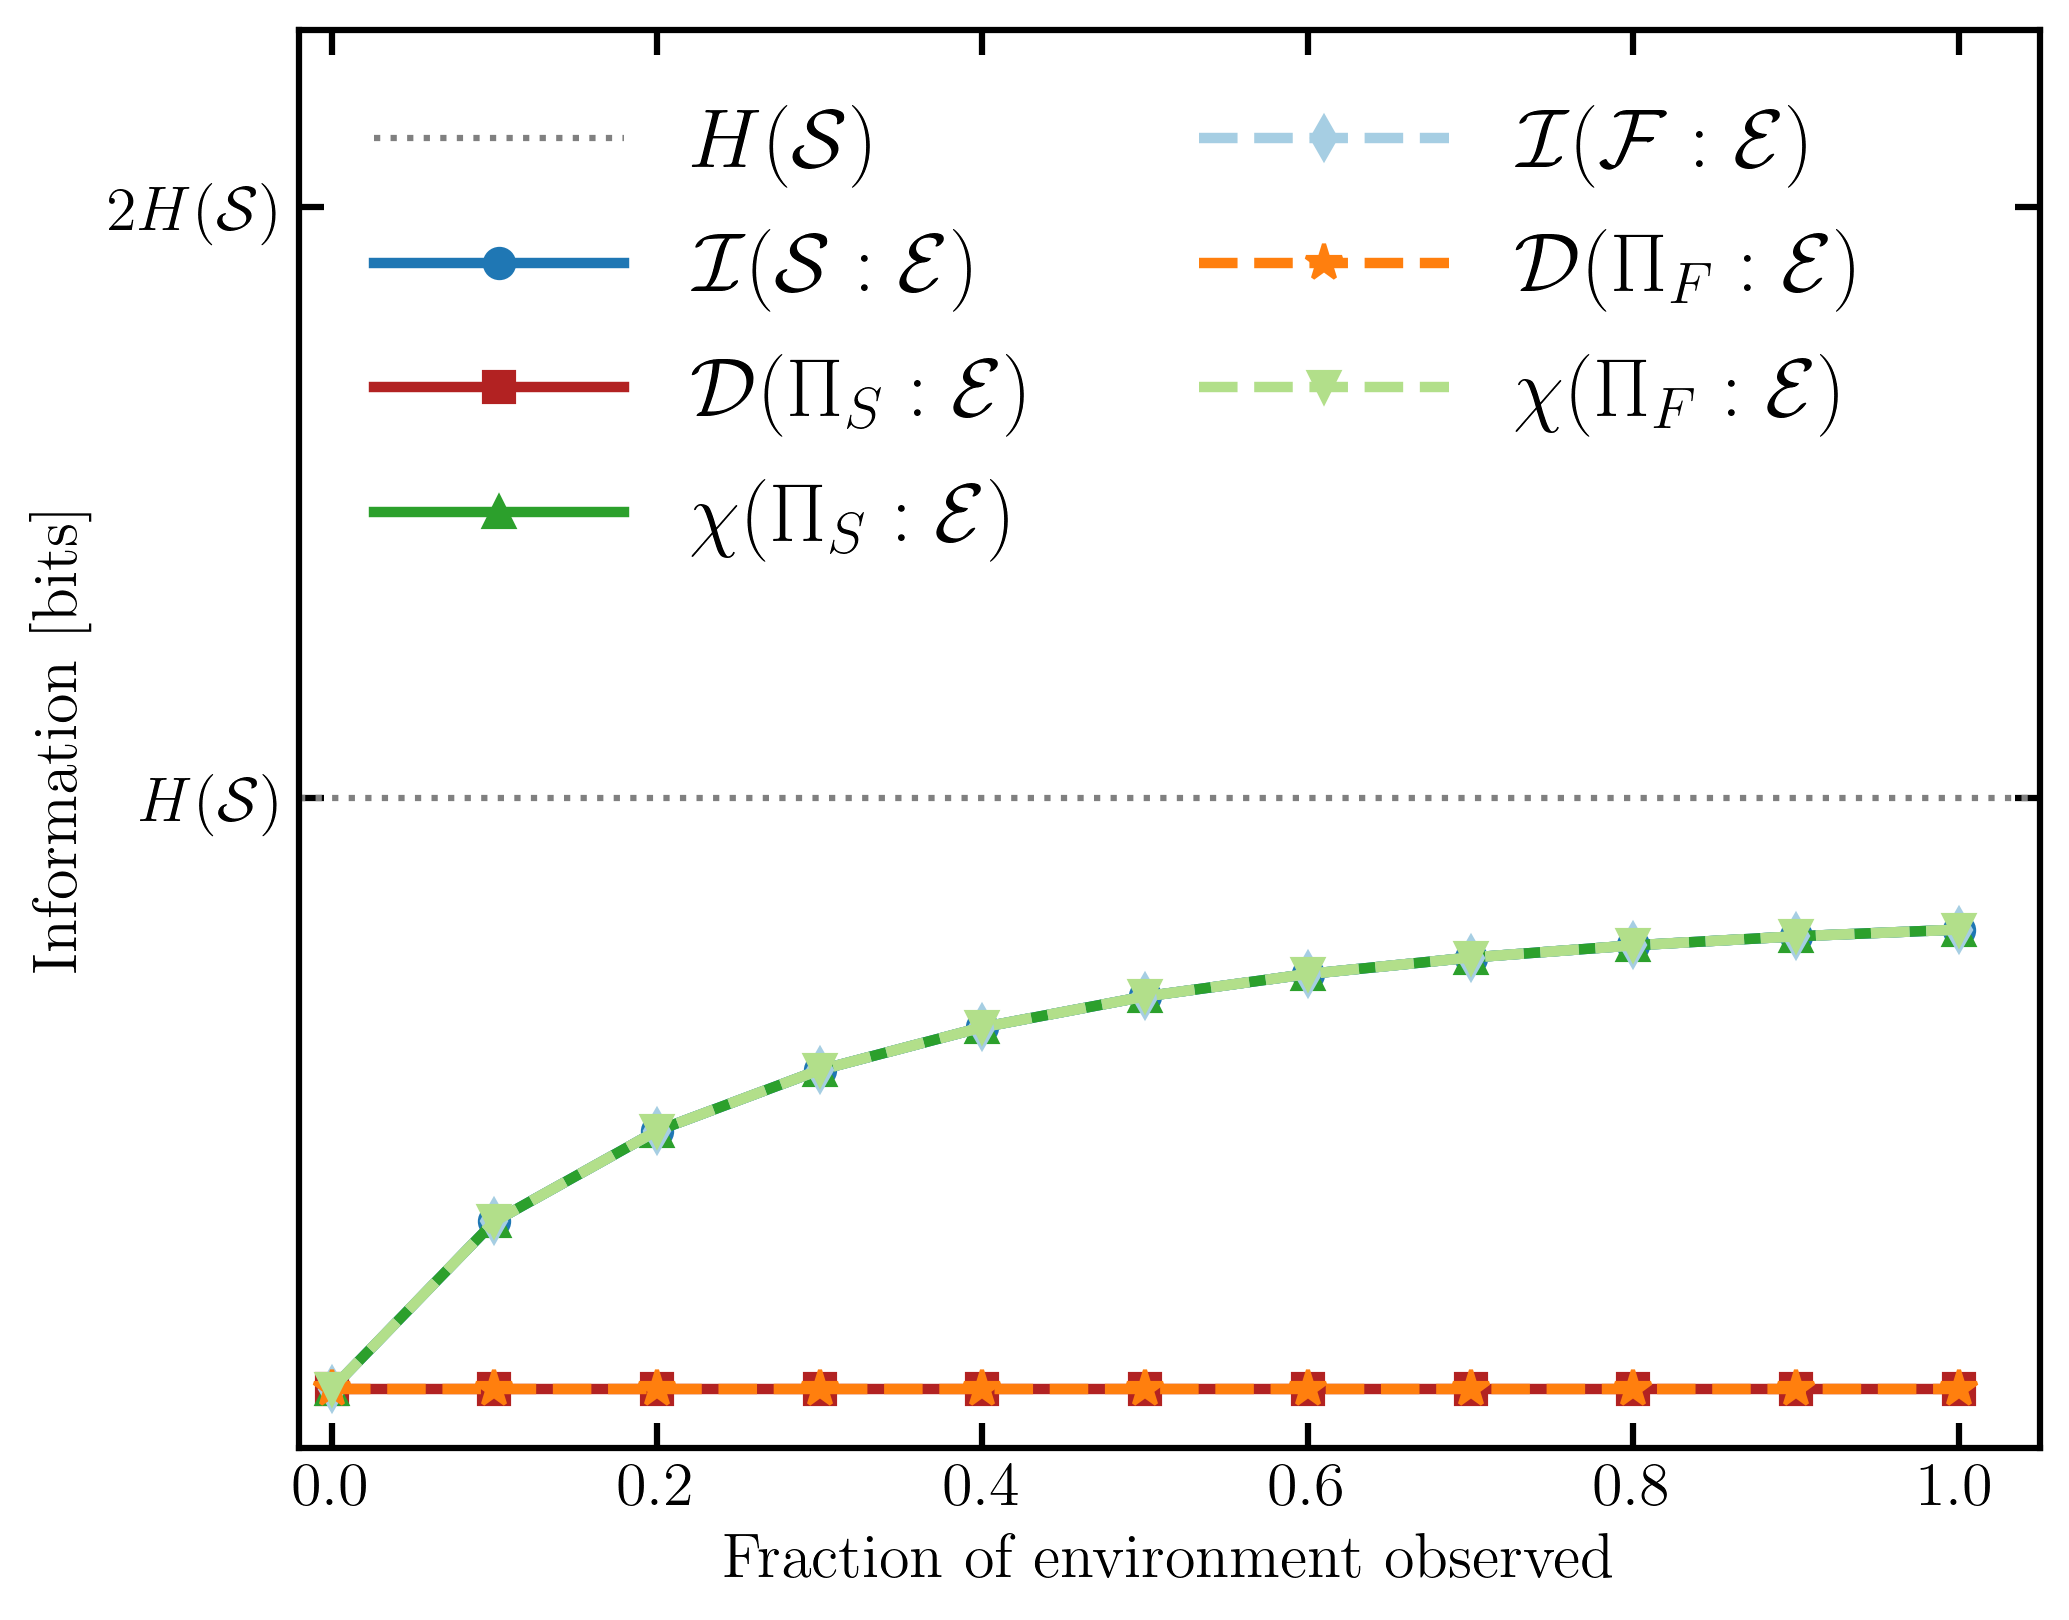

In [10]:
# ========== PLOT ==========

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os
import pickle

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern Roman']
mpl.rcParams['axes.unicode_minus'] = False

# Working directory
os.chdir("/Users/trandon/Documents/Theoretical Physics/Quantum Darwinism Simulation")

with open("quantum_darwinism_Wigner_QMI_Holevo_Discord.pkl", "rb") as f:
    data = pickle.load(f)

results_S_Envir = data["results_S_Envir"]
results_Holevo = data["results_Holevo"]
results_Discord = data["results_Discord"]

results_F_Envir = data["results_F_Envir"]
results_Holevo_F = data["results_Holevo_F"]
results_Discord_F = data["results_Discord_F"]

numQubits = 11
env_qubits = list(range(1, numQubits))

plt.figure(figsize=(7, 5.5)) # Tăng nhẹ chiều rộng để legend không đè lên đường vẽ
fs = np.array(range(1, len(env_qubits)+1)) / len(env_qubits)   # từ 0 đến 1
fs_ext = np.concatenate([[0], fs])

results_ext = np.concatenate([[0.0], results_S_Envir])
discord_ext = np.concatenate([[0.0], results_Discord])
holevo_ext = np.concatenate([[0.0], results_Holevo])

results_F_ext = np.concatenate([[0.0], results_F_Envir])
discord_F_ext = np.concatenate([[0.0], results_Discord_F])
holevo_F_ext = np.concatenate([[0.0], results_Holevo_F])

# Đường tham chiếu nền
plt.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, label=r"$H(\mathcal{S})$")

# =========================================================================
# NHÓM 1: GÓC NHÌN HỆ THỐNG (S) - Dùng Nét Liền (-), Màu Đậm, Marker Cơ Bản
# =========================================================================
# Quantum Mutual Information (S:E) - Màu Xanh Dương Đậm, hình tròn
# =========================================================================
# NHÓM 1: GÓC NHÌN WIGNER / HỆ S - Nét liền (-), Tông màu đậm chuẩn Physics
# =========================================================================
# Mutual Information (S:E) - Xanh dương đậm (Navy/Royal Blue)
plt.plot(fs_ext, results_ext, color='#1f77b4', linestyle='-', marker='o', 
         linewidth=2.5, markersize=7, label=r"$\mathcal{I}(\mathcal{S}:\mathcal{E})$")

# Quantum Discord (S:E) - Đỏ sẫm (Crimson/Burgundy)
plt.plot(fs_ext, discord_ext, color='#b22222', linestyle='-', marker='s', 
         linewidth=2.5, markersize=7, label=r"$\mathcal{D}(\Pi_{S}:\mathcal{E})$")

# Holevo Bound (S:E) - Xanh lá thông (Forest Green)
plt.plot(fs_ext, holevo_ext, color='#2ca02c', linestyle='-', marker='^', 
         linewidth=2.5, markersize=7, label=r"$\chi(\Pi_S:\mathcal{E})$")

# =========================================================================
# NHÓM 2: GÓC NHÌN NGƯỜI BẠN (F) - Nét đứt (--), Tông khoa học phối sợi
# =========================================================================
# Mutual Information (F:E) - Xanh da trời dịu (Sky Blue) -> Cặp với Xanh dương
plt.plot(fs_ext, results_F_ext, color='#a6cee3', linestyle='--', marker='d', 
         linewidth=2.5, markersize=7, label=r"$\mathcal{I}(\mathcal{F}:\mathcal{E})$")

# Quantum Discord (F:E) - Màu cam đất/hổ phách (Amber/Muted Orange) -> Cặp với Đỏ
plt.plot(fs_ext, discord_F_ext, color='#ff7f0e', linestyle='--', marker='*', 
         linewidth=2.5, markersize=9, label=r"$\mathcal{D}(\Pi_{F}:\mathcal{E})$")

# Holevo Bound (F:E) - Xanh lá mạ nhạt (Sage/Light Green) -> Cặp với Xanh lá đậm
plt.plot(fs_ext, holevo_F_ext, color='#b2df8a', linestyle='--', marker='v', 
         linewidth=2.5, markersize=7, label=r"$\chi(\Pi_F:\mathcal{E})$")

# =========================================================================
# CẤU HÌNH TRỤC TỌA ĐỘ & LABEL (Giữ nguyên form chuẩn của bạn)
# =========================================================================
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(width=1.5, length=6, direction="in", top=True, right=True)

yticks = [1.0, 2.0]
labels = [r"$H(\mathcal{S})$", r"$2H(\mathcal{S})$"]
plt.yticks(yticks, labels, fontsize=15)
plt.xticks(fontsize=15)
plt.xlabel('Fraction of environment observed', fontsize=15)
plt.ylabel('Information [bits]', fontsize=15)
plt.title('', fontsize=15, fontweight='bold')

# Đẩy Legend ra góc bên phải hoặc góc tối ưu, bật hiển thị 2 cột nếu cần cho gọn
plt.legend(fontsize=20, frameon=False, loc='upper left', handlelength=3, ncol=2)
plt.grid(False)
plt.xlim(-0.02, 1.05)
plt.ylim(-0.1, 2.3) # Giới hạn biên dọc rộng một chút để không che khuất đồ thị
plt.tight_layout()
plt.show()

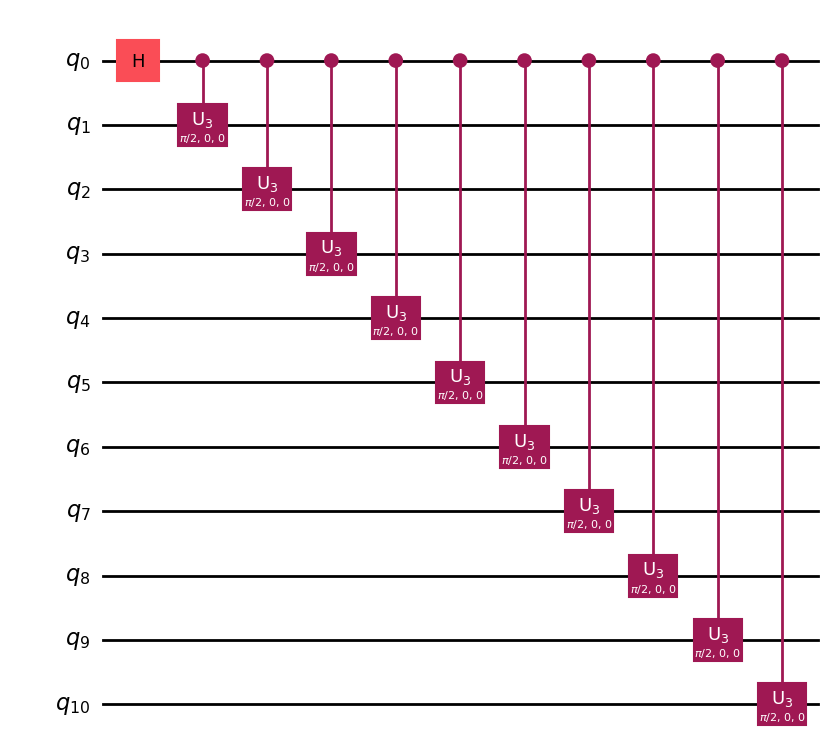

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import U3Gate
from IPython.display import display

class QCircuit:    
    def __init__(self, theta, phi, n):  
        self.theta = theta   
        self.phi = phi       
        self.n = n           

    def Circuit(self): 
        qc = QuantumCircuit(self.n)
        qb_sys   = 0
        qb_envir = list(range(1, self.n))
        
        # System prepare |+> bằng Hadamard
        qc.h(qb_sys)
        
        # System entangled with environment bằng controlled-U3
        for i in qb_envir:
            cu_gate = U3Gate(self.theta, self.phi, 0).control(1)
            qc.append(cu_gate, [qb_sys, i])
        return qc 

numQubits = 11
theta, phi = np.pi/2, 0
qc = QCircuit(theta, phi, numQubits).Circuit()

# Vẽ mạch, sẽ thấy ký hiệu H
display(qc.draw('mpl'))
